<a href="https://colab.research.google.com/github/jnolorbe/hydrology-peru/blob/main/notebooks/02_spatiotemporal_trends_and_enso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. Spatiotemporal Trends and ENSO Teleconection

**Project:** Spatio-temporal Analysis of Hydrological Response in Peru (2002-2025)

**Author:** Prof. Juan Mendoza-Nolorbe  

**Affiliations:** UNMSM

**Phase 2:** Spatiotemporal Trend Analysis and Climate Teleconnections

---
### Overview: Statistical Analysis Pipeline

This notebook provides a comprehensive assessment of the spatio-temporal dynamics of water storage in Peru. The workflow includes:

- **Dataset Loading and Spatial Preprocessing:** Integration of the curated GRACE/GRACE-FO product and administrative boundaries (Shapefiles) to define the fourteen national hydrographic domains.

- **Exploratory Statistics and Climatology:** Generation of historical water storage "balance sheets" for each domain and visualization of seasonal climatology to understand the peak recharge and discharge months.

- **Domain Correlation Analysis:** Quantitative comparison of Terrestrial Water Storage (TWS) anomalies across different hydrographic regions to evaluate the degree of synchronization in the hydrological response across the Andes.

- **Spatio-Temporal Progression (Hovmöller):** Construction of Hovmöller diagrams to visualize the latitudinal evolution of TWS anomalies across hydrographic domains. By integrating oceanic indices (ONI & ICEN) into the temporal axis, this analysis identifies the propagation of extreme hydrological events and quantifies the direct impact of El Niño/La Niña cycles from 2002 to 2025.



# I. Fundamentals of Analysis




## 1.1. Spatial Aggregation by Hydrological Domains

Peru is geographically divided into three macro-regions: the Coast, the Andean highlands (Sierra), and the Amazon (Selva), each characterized by contrasting climates. The Coast corresponds to the Pacific drainage basin, while the Amazon belongs to the Atlantic drainage basin, with the Andes acting as the headwaters. In this context, the country is administratively divided into **14 hydrological domains** (Section I & II). By aggregating the satellite signal into these 14 domains, this study addresses the Terrestrial Water Storage (TWS) cycle as measured by the GRACE mission and its teleconnection with ENSO events.



## 1.2. Cross-Domain Synchronization

The Andes Cordillera acts as a major climate divide. The Correlation Analysis (Section III) measures how hydrological anomalies on one side of the mountains (Atlantic/Amazon) influence or reflect the behavior on the other side (Pacific/Coast), revealing national-scale climate patterns.


## 1.3. Latitudinal Dynamics (Hovmöller Diagrams)

Time-series plots often hide the spatial movement of anomalies. The Hovmöller Analysis (Section IV) collapses longitude to show how droughts or water surpluses travel latitudinally. This is essential for detecting the geographical footprint of phenomena that affect the North, Center, or South of Peru differently.

# II. Libraries and Loading Data

## 2.1 Install and Import Libraries

In [ ]:
# Installing libraries for NetCDF
!pip install cmcrameri
!pip install netCDF4 xarray rioxarray geopandas shapely openpyxl


In [2]:
# Import essential libraries
import numpy as np
import xarray as xr
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import rioxarray
import os

In [3]:
# Setting parameters for high-quality figure rendering
import matplotlib as mpl

# === 1. FONT EMBEDDING AND FAMILY ===
# Force TrueType fonts (Type 42) to ensure proper embedding in PDF
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Set default font family to Sans-Serif
plt.rcParams['font.family'] = 'sans-serif'
# Try using Arial or Helvetica; if unavailable, fall back to Colab's default (DejaVu Sans)
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans']

# === 2. LEGIBLE FONT SIZES ===
# Ensures text remains readable even when figures are scaled down
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# === 3. LINE THICKNESS (Guideline: High-quality line graphics) ===
plt.rcParams['lines.linewidth'] = 1.0  # Líneas claras
plt.rcParams['axes.linewidth'] = 1.0   # Bordes del gráfico claros

## 2.2 Repository Synchronization

In [ ]:
# Define repository metadata
REPO_NAME = "hydrology-peru"
GITHUB_USERNAME = "jnolorbe" # Change this if you fork the repo
REPO_URL = f"https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"

# Clone to access processed data and shapefiles
if not os.path.exists(REPO_NAME):
    print("Status: Cloning repository...")
    !git clone {REPO_URL}
else:
    %cd {REPO_NAME}
    !git pull
    %cd ..

## 2.3 Loading Data GRACE Mascon (Processed)

In [ ]:
# --- Loading Data GRACE Processed ---
# Define relative paths to the cloned repository structure
data_grace_path = f"{REPO_NAME}/data/processed/GRACE_Peru_final_IQR1_5.nc"

# Load GRACE/GRACE-FO Peru dataset
try:
    xr_grace = xr.open_dataset(data_grace_path)
    print(f"Success: Global dataset loaded. Time steps: {len(xr_grace.time)}")
except FileNotFoundError:
    print("Error: NetCDF file not found. Check the data/raw/ directory.")

# --- Metadata Configuration ---
# Update dataset attributes to comply with CF (Climate and Forecast) conventions
# This ensures compatibility with spatial analysis libraries like rioxarray
new_attrs = {
    "long_name": "Equivalent Water Height",
    "units": "cm",
    "transform": (1, 0.0, 0.0, 0.0, -1.0, 0.0),
    "crs": "+init=epsg:4326",
    "ellipsoid": "WGS84",
    "res": (0.5, 0.5),
    "nodatavals": "nan"
}
xr_grace.attrs.update(new_attrs)

# Remove non-essential dimensions or variables to streamline processing
xr_grace = xr_grace.drop_vars('month')

# --- STEP 3: Anomaly Calculation (Centering) ---
# Calculate the long-term mean to derive Terrestrial Water Storage (TWS) anomalies
long_term_mean = xr_grace['lwe_thickness_corrected'].mean('time')

# Create a new variable representing the centered data (Observation - Mean)
xr_grace['lwe_thickness_centered'] = xr_grace['lwe_thickness_corrected'] - long_term_mean

# Display the updated dataset structure for verification
display(xr_grace)


## 2.4 Loading Hydrological Domains (Shapefiles)

In [ ]:
# --- Loading Hydrologycal Domains ---

# Path to the AAA (Autoridad Administrativa del Agua) shapefile
AAA_SHAPEFILE_PATH = f"{REPO_NAME}/data/shapefiles/hydroAAA_domains/Autoridad_Administrativa_del_Agua.shp"

# Loading and validating the Administrative Domains (AAA)
try:
    # Load the shapefile from the local path of the cloned repository
    gdf_aaa = gpd.read_file(AAA_SHAPEFILE_PATH)

    # Ensure the Coordinate Reference System (CRS) matches the GRACE data (WGS84)
    if gdf_aaa.crs != "EPSG:4326":
        gdf_aaa = gdf_aaa.to_crs(epsg=4326)
        print("Status: Shapefile reprojected to EPSG:4326 (WGS84).")

    print(f"Status: 14 AAA domains loaded successfully.")

    # Optional: Display attribute table and spatial verification
    display(gdf_aaa)

except Exception as e:
    print(f"[ERROR] Failed to load the shapefile. Verify the file path or content: {e}")

## 2.5 Visualizing Hydrological Domains

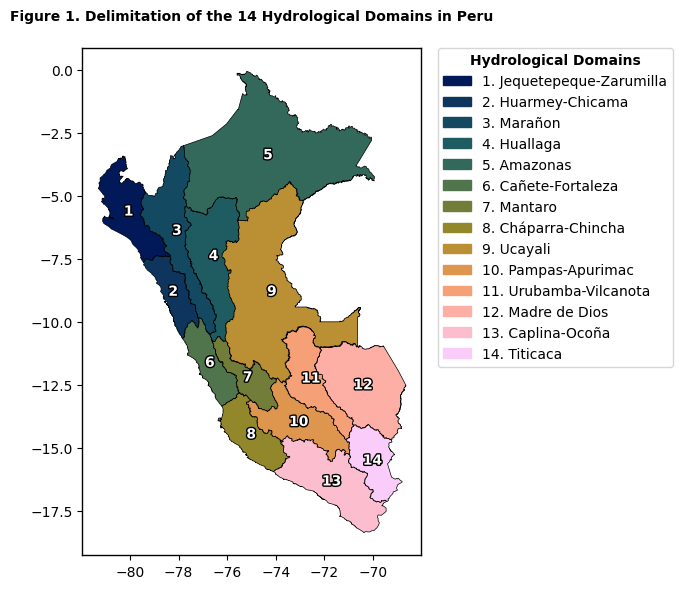

In [113]:
# --- Visualizing Hydrographic Domains with Batlow Palette ---
import matplotlib.patheffects as patheffects
import matplotlib.patches as mpatches
import cmcrameri.cm as cmc

# Define the Batlow perceptually uniform colormap for 14 domains
colores_batlow = cmc.batlow(np.linspace(0, 1, 14))

# Mapping OBJECTID_1 (CODE_AAA) to labels and colors
# The order follows the hydrological/latitudinal logic of the study
region_plotting_order = [
    (5, 'Jequetepeque-Zarumilla'), # colores_batlow[0]
    (4, 'Huarmey-Chicama'),        # colores_batlow[1]
    (6, 'Marañon'),                # colores_batlow[2]
    (8, 'Huallaga'),               # colores_batlow[3]
    (7, 'Amazonas'),               # colores_batlow[4]
    (3, 'Cañete-Fortaleza'),       # colores_batlow[5]
    (10, 'Mantaro'),               # colores_batlow[6]
    (2, 'Cháparra-Chincha'),       # colores_batlow[7]
    (9, 'Ucayali'),                # colores_batlow[8]
    (11, 'Pampas-Apurimac'),       # colores_batlow[9]
    (12, 'Urubamba-Vilcanota'),    # colores_batlow[10]
    (13, 'Madre de Dios'),         # colores_batlow[11]
    (1, 'Caplina-Ocoña'),          # colores_batlow[12]
    (14, 'Titicaca')               # colores_batlow[13]
]

# Create dictionary for mapping {CODE_AAA: {'label': label, 'color': color, 'plotting_order_index': index}}
region_details_for_plot = {}
for i, (obj_id, label) in enumerate(region_plotting_order):
    region_details_for_plot[obj_id] = {
        'label': label,
        'color': colores_batlow[i],
        'plotting_order_index': i + 1 # Add the consecutive number
    }

# Visualization setup
fig, ax = plt.subplots(figsize=(8, 6))

# Plot each region individually to apply the specific Batlow color mapping
for obj_id, details in region_details_for_plot.items():
    # Filter the GeoDataFrame for the specific AAA code
    region_geometry = gdf_aaa[gdf_aaa['CODE_AAA'] == obj_id]

    if not region_geometry.empty:
        # Plot geometry
        region_geometry.plot(
            ax=ax,
            color=details['color'],
            edgecolor='black',
            linewidth=0.5
        )

        # Reproject to a suitable projected CRS (e.g., Web Mercator) for accurate centroid calculation
        # Then convert the centroid back to the original CRS for plotting text
        centroid_projected = region_geometry.to_crs(epsg=3857).geometry.centroid.iloc[0]
        centroid_original_crs = gpd.GeoSeries([centroid_projected], crs='epsg:3857').to_crs(epsg=4326).iloc[0]

        # Add numbering to centroids for spatial identification
        ax.text(
            centroid_original_crs.x, centroid_original_crs.y, str(details['plotting_order_index']),
            fontsize=10, ha='center', va='center',
            color='white', weight='bold',
            path_effects=[patheffects.withStroke(linewidth=2, foreground='black')]
        )

# Create custom legend handles with scientific labels
legend_handles = [
    mpatches.Patch(color=details['color'], label=f"{details['plotting_order_index']}. {details['label']}")
    for obj_id, details in region_details_for_plot.items()
]

# Formatting the plot for publication
ax.set_title("Figure 1. Delimitation of the 14 Hydrological Domains in Peru",
              fontweight='bold', pad=20)
# ax.set_axis_off() # Removed to show axes and grid
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)

# Place legend outside the plot
ax.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=10,
    title='Hydrological Domains',
    title_fontproperties={'weight': 'bold'}
)

plt.tight_layout()
plt.show()
plt.close()

## 2.6 Preliminary inspection

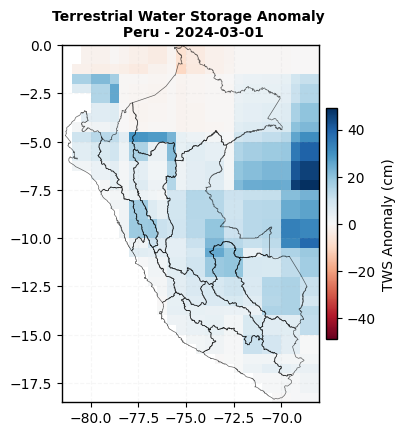

In [111]:
## Spatial inspection

# --- Target date selection ---
target_date = '2024-03-01'
#tws_map = ds_peru_box['lwe_thickness'].sel(time=target_date, method='nearest')
tws_map = xr_grace['lwe_thickness_centered'].sel(time=target_date, method='nearest')
# --- Map Visualization ---
fig, ax = plt.subplots(figsize=(4, 5))

# Plotting GRACE data using 'RdBu' (Red for drought, Blue for wetness)
im = tws_map.plot(ax=ax, cmap='RdBu', center=0, add_colorbar=False)

# --- Overlaying the ANA Shapefile (Basin boundaries)---
# Using the shapefile loaded in previous sections
gdf_aaa.boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=0.6)

# --- Map Customization ---
plt.title(f"Terrestrial Water Storage Anomaly \n Peru - {str(tws_map.time.values)[:10]}", fontweight='bold')
plt.xlabel("")
plt.ylabel("")

# Customizing the Colorbar
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.6)
cbar.set_label('TWS Anomaly (cm)')

plt.grid(True, linestyle='--', alpha=0.1)
plt.show()
plt.close(fig)

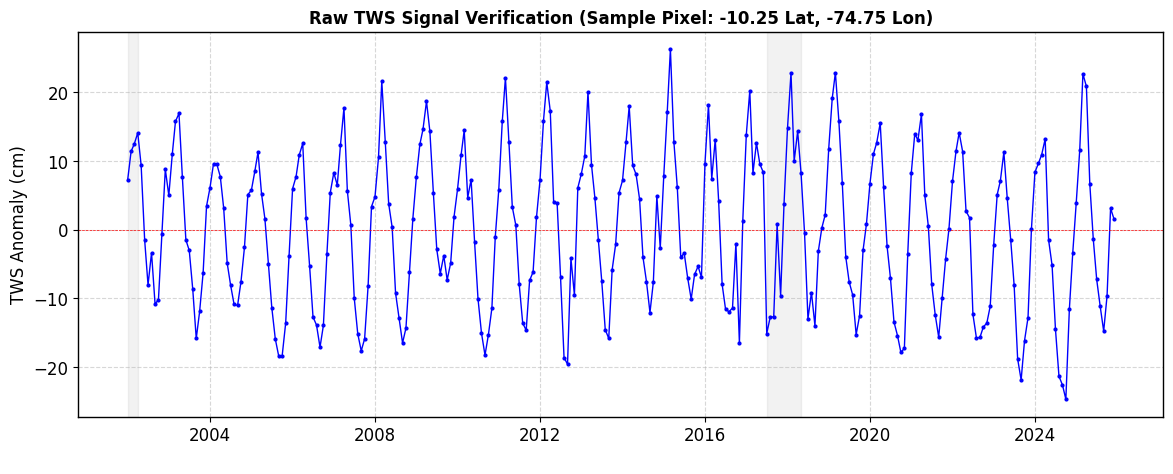

In [106]:
## Temporal Inspection

# --- Representative pixel in Perú ---
pixel_lat, pixel_lon = -10.25, -74.75

# --- Extracting the Time Series --
# Selecting the nearest pixel
ts_pixel = xr_grace['lwe_thickness_centered'].sel(lat=pixel_lat, lon=pixel_lon, method='nearest')

# --- Visualization ---
plt.figure(figsize=(14, 5))

# Plotting with markers to clearly identify individual data points and gaps
ts_pixel.plot(marker='o', markersize=2, linestyle='-', linewidth=1,label='Scaled TWS (cm)',  color='blue')

# Highlighting periods with missing data that were subsequently imputed (2002-01 to 2002-03 will be empty)
plt.axvspan('2002-01-01', '2002-04-01', color='gray', alpha=0.1, label='Pre-mission Period (NaNs)')
plt.axvspan('2017-07-01', '2018-05-01', color='gray', alpha=0.1, label='Gap GRACE / GRACE FO Period (NaNs)')

# --- Customization and Context ---
plt.title(f"Raw TWS Signal Verification (Sample Pixel: {pixel_lat} Lat, {pixel_lon} Lon)", fontsize=12, fontweight='bold')
plt.ylabel("TWS Anomaly (cm)", fontsize=12)
plt.xlabel(" ")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.axhline(0, color='red', linestyle='--', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()
plt.close()


# III. Time Series Generation by Domain


## 3.1 Spatial Clipping (14 Domains)


In [ ]:
# --- Spatial Clipping ---
# Ensure the GRACE data has the correct CRS assigned
grace_anomaly_crs = xr_grace['lwe_thickness_centered'].rio.write_crs("EPSG:4326")

# Dictionary to store the clipped DataArrays for each domain
grace_clipped_domains = {}

# List of unique CODE_AAA to iterate through
domain_ids = gdf_aaa['CODE_AAA'].unique()

print("Status: Starting spatial clipping. Filtering for largest geometry per domain...")

for obj_id in domain_ids:
    # 1. Filter all geometries sharing the same CODE_AAA
    domain_geoms = gdf_aaa[gdf_aaa['CODE_AAA'] == obj_id].copy()

    if not domain_geoms.empty:
        # 2. Identify the largest geometry to avoid small fragments (e.g., in Ucayali)
        # We calculate the area to ensure we select the main hydrological body
        domain_geoms['area_calc'] = domain_geoms.geometry.area
        main_geometry = domain_geoms.sort_values(by='area_calc', ascending=False).head(1)

        domain_name = main_geometry['NAME_AAA'].iloc[0]

        # 3. Perform the spatial clip using only the main geometry
        clipped_data = grace_anomaly_crs.rio.clip(
            main_geometry.geometry,
            main_geometry.crs,
            drop=True
        )

        # Store in dictionary
        grace_clipped_domains[obj_id] = clipped_data

        print(f"  > Domain {obj_id} ({domain_name}) processed using largest polygon.")

print("\n[SUCCESS] Spatial clipping completed for all main hydrological bodies.")

## 3.2 Calculation of Spatial Mean Time Series


In [ ]:
# --- Calculation of Spatial Mean Time Series --- #
# --- Centered Quarterly Moving Average (Smoothing) --- #
# Dictionary to store the 1D time series for each domain
ts_dict = {}

print("Status: Calculating spatial mean for each domain...")

for obj_id, clipped_da in grace_clipped_domains.items():
    # 1. Calculate the spatial mean (weighted average across lat/lon)
    # We collapse the spatial dimensions while preserving the time dimension
    spatial_mean = clipped_da.mean(dim=['lat', 'lon'])

    # 2. Get the domain name for the column header
    # Searching for the name in our GeoDataFrame based on the ID
    domain_name = gdf_aaa[gdf_aaa['CODE_AAA'] == obj_id]['NAME_AAA'].iloc[0]

    # 3. Convert to a Pandas Series
    ts_dict[domain_name] = spatial_mean.to_series()

# 4. Create the final DataFrame
# Each column represents a Hydrographic Domain (AAA)
df_tws_final = pd.DataFrame(ts_dict)

# 5. Clean indexing
df_tws_final.index.name = 'Date'
df_tws_final.sort_index(inplace=True)

print("\n[SUCCESS] Time series extraction completed.")
print(f"DataFrame shape: {df_tws_final.shape} (Months x Domains)")

# --- Apply Centered Quarterly Moving Average (Smoothing) ---
print("Status: Applying centered quarterly moving average to df_tws_final...")
df_tws_final = df_tws_final.rolling(window=3, center=True).mean()
print("[SUCCESS] df_tws_final smoothed with centered quarterly moving average.")

print(f"DataFrame shape after smoothing: {df_tws_final.shape}")
display(df_tws_final.head())

## 3.3 Times Series Visualization


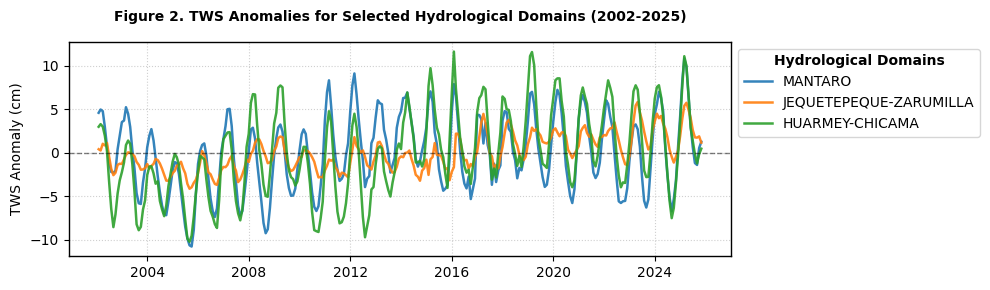

In [20]:
# --- Time Series Visualization (Selected Domains) ---

# 1. Manual selection of domains to visualize
# You can modify this list using the exact names from your DataFrame columns
selected_domains = ['MANTARO', 'JEQUETEPEQUE-ZARUMILLA', 'HUARMEY-CHICAMA']

# 2. Setup plotting parameters for publication quality
plt.figure(figsize=(10, 3))

# Use the Batlow color palette consistent with the map (Step 5)
# We select colors based on the index to maintain identity
for i, domain in enumerate(selected_domains):
    if domain in df_tws_final.columns:
        plt.plot(df_tws_final.index, df_tws_final[domain],
                 label=domain,
                 linewidth=1.8,
                 alpha=0.9)
    else:
        print(f"Warning: Domain '{domain}' not found in the dataset.")

# 3. Scientific Chart Formatting
plt.title('Figure 2. TWS Anomalies for Selected Hydrological Domains (2002-2025)',
           pad=15,fontweight='bold')
plt.xlabel('')
plt.ylabel('TWS Anomaly (cm)')

# Adding a horizontal line at zero to highlight positive/negative anomalies
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# Legend and Grid
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Hydrological Domains',
           title_fontproperties={'weight': 'bold'},frameon=True)
plt.grid(True, which='both', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
plt.close()

# IV. Time Series Decomposition

Terrestrial Water Storage ($TWS$) signal can be expressed as:

$$TWS(t) = Trend(t) + Seasonal(t) + Residual(t)$$

## 4.1 Additive Decomposition

In [22]:
# --- Additive Decomposition (Batch Processing) ---
from statsmodels.tsa.seasonal import seasonal_decompose

# Dictionaries to store the decomposed components
dict_seasonal = {}
dict_trend = {}
dict_resid = {}

print("Status: Performing additive decomposition for 14 domains...")

# Drop NaN values introduced by the centered moving average
# This ensures seasonal_decompose can process the data without errors
df_tws_clean = df_tws_final.dropna()

for domain in df_tws_clean.columns:
    # We assume a period of 12 months for the annual cycle
    # 'extrapolate_trend' handles the edges of the time series
    result = seasonal_decompose(df_tws_clean[domain], model='additive', period=12, extrapolate_trend='freq')

    dict_seasonal[domain] = result.seasonal
    dict_trend[domain] = result.trend
    dict_resid[domain] = result.resid

# Convert dictionaries to DataFrames for easier analysis
df_seasonal = pd.DataFrame(dict_seasonal)
df_trend = pd.DataFrame(dict_trend)
df_residual = pd.DataFrame(dict_resid)
print("[SUCCESS] Decomposition completed.")

Status: Performing additive decomposition for 14 domains...
[SUCCESS] Decomposition completed.


## 4.2 Deseasonalized Component

This component contains the signals of extreme events. We will visualize how the 14 domains behave once the regular seasonal "noise" is removed.

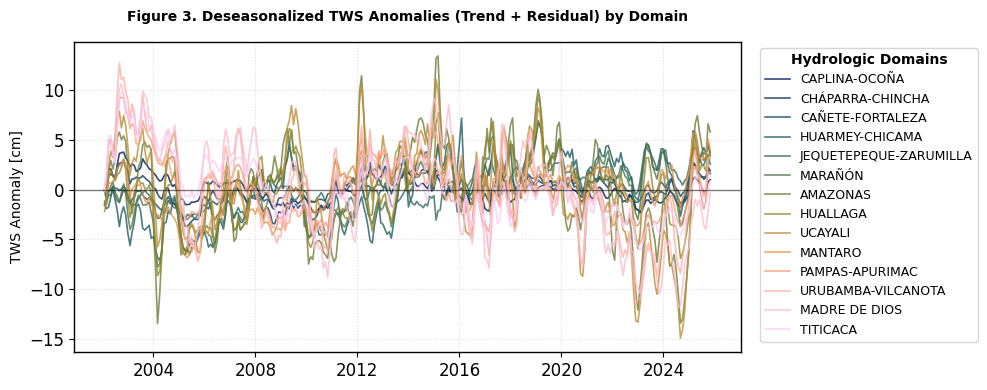

In [35]:
import cmcrameri.cm as cmc

# --- Deseasonalized Component Analysis (Trend + Residual) ---

# 1. Calculation of the Deseasonalized Signal
# Deseasonalized = Original - Seasonal OR Trend + Residual
df_deseasonalized = df_tws_final - df_seasonal

# 2. Visualization Setup
plt.figure(figsize=(10, 4))
colores_batlow = cmc.batlow(np.linspace(0, 1, 14))

# 3. Plotting loop using the same regional configuration for consistency
for i, domain in enumerate(df_deseasonalized.columns):
    # We use a thinner line and alpha to handle 14 overlapping series
    plt.plot(df_deseasonalized.index, df_deseasonalized[domain],
             label=domain,
             color=colores_batlow[i],
             linewidth=1.2,
             alpha=0.8)

# 4. Scientific Formatting (English)
plt.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
plt.title('Figure 3. Deseasonalized TWS Anomalies (Trend + Residual) by Domain',
          fontweight='bold', pad=15)

plt.ylabel('TWS Anomaly [cm]')
plt.xlabel('')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Legend configuration
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Hydrologic Domains',
           fontsize=9, title_fontproperties={'weight': 'bold'})

plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()

# Optional: Save for the journal
# plt.savefig('deseasonalized_tws_peru.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.3 Correlation Matrix of Deseasonalized TWS Anomalies

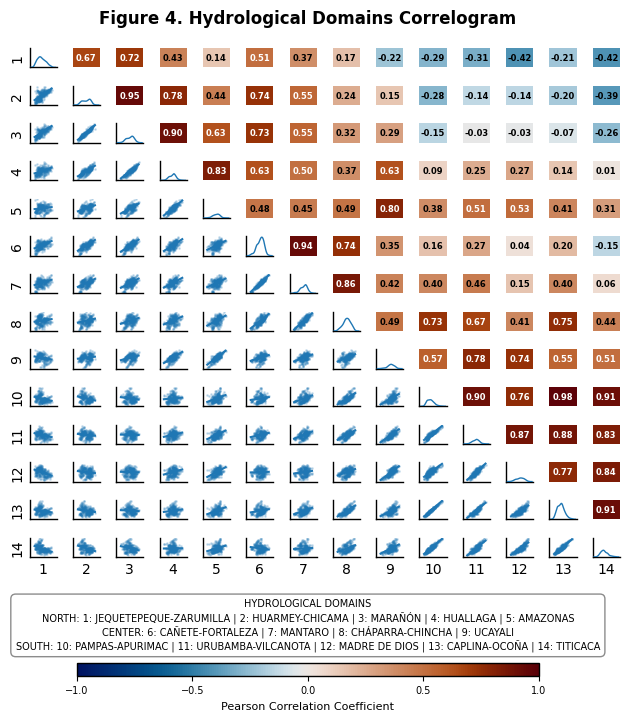

In [114]:
import seaborn as sns
from scipy.stats import pearsonr
import matplotlib.cm as cm
import matplotlib.colorbar as mcolorbar # Import for ColorbarBase
import matplotlib.colors as mcolors     # Import for Normalize

# Selection of representative domains
subset_domains = [
    'JEQUETEPEQUE-ZARUMILLA',
    'HUARMEY-CHICAMA',
    'MARAÑÓN',
    'HUALLAGA',
    'AMAZONAS',
    'CAÑETE-FORTALEZA',
    'MANTARO',
    'CHÁPARRA-CHINCHA',
    'UCAYALI',
    'PAMPAS-APURIMAC',
    'URUBAMBA-VILCANOTA',
    'MADRE DE DIOS',
    'CAPLINA-OCOÑA',
    'TITICACA'
]

# Create a mapping for numeric IDs to shorten labels
domain_mapping = {name: f"{i+1}" for i, name in enumerate(subset_domains)}

# Create a copy of the dataframe with shortened column names for plotting
df_plot = df_deseasonalized[subset_domains].dropna().rename(columns=domain_mapping)

def corrfunc(x, y, ax=None, **kws):
    r, _ = pearsonr(x, y)
    ax = ax or plt.gca()
    # Using Crameri 'vik' palette (divergent, scientific)
    # Normalizing r (-1 to 1) to (0 to 1) index for the colormap
    color_idx = (r + 1) / 2
    color = cmc.vik(color_idx)
    ax.set_facecolor(color)

    # Remove spines/borders for a cleaner look in the coefficient cells
    for spine in ax.spines.values():
        spine.set_visible(False)

    text_color = 'white' if abs(r) > 0.5 else 'black'
    ax.annotate(f'{r:.2f}', xy=(.5, .5), xycoords=ax.transAxes,
                ha='center', va='center', fontsize=6, fontweight='bold', color=text_color)

# 17cm + Margin for 3-line legend
#base_size_cm = 17
width_inch = 6.6 #base_size_cm / 2.54

# Create the PairGrid
g = sns.PairGrid(df_plot, height=width_inch/len(subset_domains))

g.map_upper(corrfunc)
g.map_lower(sns.regplot, scatter_kws={'alpha': 0.2, 's': 1})
g.map_diag(sns.kdeplot, lw=1)

# Formatting labels: Remove ticks and manage labels visibility
n_rows, n_cols = g.axes.shape
for i in range(n_rows):
    for j in range(n_cols):
        ax = g.axes[i, j]
        ax.set_xticks([])
        ax.set_yticks([])
        if j != 0: ax.set_ylabel('')
        if i != n_rows - 1: ax.set_xlabel('')

# Get the figure object from the PairGrid
fig = g.fig

# Adjust subplots to make room for the legend and the colorbar
fig.subplots_adjust(bottom=0.2)

# --- Create a Grouped Multi-line Legend ---
north = [f"{i+1}: {subset_domains[i]}" for i in range(5)]
center = [f"{i+1}: {subset_domains[i]}" for i in range(5, 9)]
south = [f"{i+1}: {subset_domains[i]}" for i in range(9, 14)]

legend_str = (
    "HYDROLOGICAL DOMAINS" + "\n" +
    "NORTH: " + " | ".join(north) + "\n" +
    "CENTER: " + " | ".join(center) + "\n" +
    "SOUTH: " + " | ".join(south)
)

# Position the legend text (above the colorbar)
fig.text(0.5, 0.06, legend_str, ha="center", fontsize=7,
         bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.9, edgecolor='gray'))

# --- Add a colorbar for the correlation values ---
cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.02]) # [left, bottom, width, height] in figure coordinates
norm = mcolors.Normalize(vmin=-1, vmax=1) # Normalization for correlation values
cbar = mcolorbar.ColorbarBase(cbar_ax, cmap=cmc.vik, norm=norm, orientation='horizontal')
cbar.set_label('Pearson Correlation Coefficient', fontsize=8) # Smaller font for label
cbar.ax.tick_params(labelsize=7) # Smaller ticks
cbar.set_ticks([-1, -0.5, 0, 0.5, 1]) # Set specific ticks for clarity

fig.suptitle('Figure 4. Hydrological Domains Correlogram',
          fontweight='bold', y=1.03)
plt.show()
plt.close(fig)

## 4.4 Seasonal Component Extraction

The seasonal component represents the regular annual cycle of recharge and discharge in each basin.

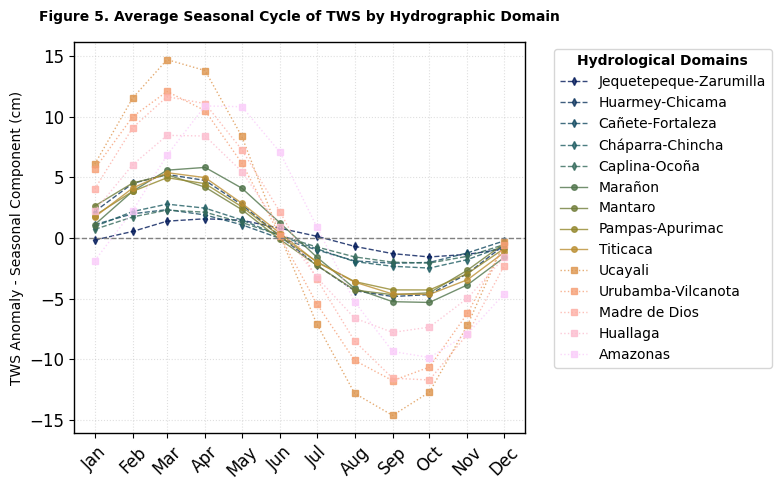

In [51]:
# --- Seasonal Component Analysis (Climatology) ---

# 1. Visualization Setup
plt.figure(figsize=(8, 5))
colores_batlow = cmc.batlow(np.linspace(0, 1, 14))

# We select a representative hydrological year (e.g., 2010) to visualize the cycle
year_to_plot = '2010'
seasonal_subset = df_seasonal.loc[year_to_plot]

# 2. Define Regional Groupings for consistent plotting styles
# (Label in DataFrame, Custom Label for Legend, Color Index, Line Style, Marker)
regions_config = [
    # Coastal domains (Pacific Basin)
    ('JEQUETEPEQUE-ZARUMILLA', 'Jequetepeque-Zarumilla', 0, '--', 'd'),
    ('HUARMEY-CHICAMA', 'Huarmey-Chicama', 1, '--', 'd'),
    ('CAÑETE-FORTALEZA', 'Cañete-Fortaleza', 2, '--', 'd'),
    ('CHÁPARRA-CHINCHA', 'Cháparra-Chincha', 3, '--', 'd'),
    ('CAPLINA-OCOÑA', 'Caplina-Ocoña', 4, '--', 'd'),

    # Andean domains (Highlands)
    ('MARAÑÓN', 'Marañon', 5, '-', 'o'), # Corrected to match df_tws_final column name
    ('MANTARO', 'Mantaro', 6, '-', 'o'),
    ('PAMPAS-APURIMAC', 'Pampas-Apurimac', 7, '-', 'o'),
    ('TITICACA', 'Titicaca', 8, '-', 'o'),

    # Amazonian domains (Atlantic Basin)
    ('UCAYALI', 'Ucayali', 9, ':', 's'),
    ('URUBAMBA-VILCANOTA', 'Urubamba-Vilcanota', 10, ':', 's'), # Corrected to match df_tws_final column name
    ('MADRE DE DIOS', 'Madre de Dios', 11, ':', 's'),
    ('HUALLAGA', 'Huallaga', 12, ':', 's'),
    ('AMAZONAS', 'Amazonas', 13, ':', 's')
]

# 3. Plotting loop
for df_label, legend_label, color_idx, l_style, m_style in regions_config:
    if df_label in seasonal_subset.columns:
        plt.plot(seasonal_subset.index, seasonal_subset[df_label],
                 label=legend_label,
                 color=colores_batlow[color_idx],
                 linestyle=l_style,
                 marker=m_style,
                 markersize=4,
                 alpha=0.8)

# 4. Scientific Formatting (English)
month_labels = seasonal_subset.index.strftime('%b')
plt.xticks(seasonal_subset.index, labels=month_labels, rotation=45,  fontsize=12) # Added rotation
plt.yticks(fontsize=12)
plt.axhline(0, color='gray', linestyle='--')
plt.title(f'Figure 5. Average Seasonal Cycle of TWS by Hydrographic Domain',
          fontweight='bold', pad=15)
plt.ylabel('TWS Anomaly - Seasonal Component (cm)')
plt.xlabel('')

# Legend placement outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Hydrological Domains',
           title_fontproperties={'weight': 'bold'})

plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()

plt.show()
plt.close()

# V. ONI and ICEN Teleconnections

In this section, we analyze the relationship between regional hydrological anomalies and the El Niño-Southern Oscillation (ENSO) drivers. We integrate the Oceanic Niño Index (ONI) and the Indice Costero El Niño (ICEN) to evaluate their impact on terrestrial water storage.

## 5.1 Data ONI and ICEN

In [ ]:
# --- Loading ENSO Indices (ONI & ICEN)---

# Define internal paths within the cloned repository
# REPO_NAME ya fue definido en la celda de clonación anterior
ONI_PATH = os.path.join(REPO_NAME, "data/enso/oni_2002_2025.csv")
ICEN_PATH = os.path.join(REPO_NAME, "data/enso/icen_2002_2025.csv")

# 1. Processing ONI (Oceanic Niño Index - Central Pacific)
if os.path.exists(ONI_PATH):
    df_oni = pd.read_csv(ONI_PATH, index_col='time')
    df_oni.index = pd.to_datetime(df_oni.index)
    print("Status: ONI index loaded successfully from local repository.")
else:
    print(f"Error: ONI file not found at {ONI_PATH}")

# 2. Processing ICEN (Coastal El Niño Index - Peru Coast)
if os.path.exists(ICEN_PATH):
    df_icen = pd.read_csv(ICEN_PATH, index_col='time')
    df_icen.index = pd.to_datetime(df_icen.index)
    print("Status: ICEN index loaded successfully from local repository.")
else:
    print(f"Error: ICEN file not found at {ICEN_PATH}")

# Display first rows to verify temporal alignment
print("\n--- Preliminary ONI Data Check ---")
print(df_oni.head(3))

# Display first rows to verify temporal alignment
print("\n--- Preliminary ICEN Data Check ---")
print(df_icen.head(3))

## 5.2 Spatiotemporal Evolution: Hovmöller

DiagramThe Hovmöller diagram is a powerful tool to visualize the latitudinal propagation of $TWS$ anomalies over time. By ordering domains from North to South, we can identify coherent patterns of drought or water surplus across the Peruvian territory.4.2 Hovmöller Diagram

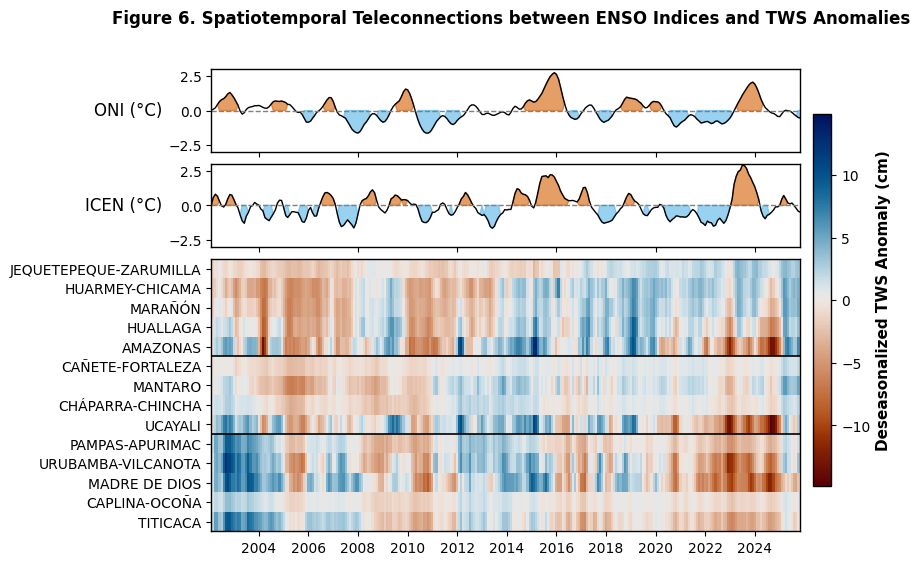

In [54]:
# --- MULTI-PANEL HOVMÖLLER DIAGRAM (ONI + ICEN + TWS) ---
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import cmcrameri.cm as cmc

# --- PREPARING TWS DATA (DESEASONALIZED) ---
# We use the deseasonalized DataFrame (Trend + Residual)
# Defining the geographical order for North-to-South analysis
ordered_domain_names = [
    # --- NORTH BLOCK (Equatorial Influence / Coastal El Niño) ---
    'JEQUETEPEQUE-ZARUMILLA', 'HUARMEY-CHICAMA', 'MARAÑÓN', 'HUALLAGA', 'AMAZONAS',

    # --- CENTRAL BLOCK (Transition Zone) ---
    'CAÑETE-FORTALEZA', 'MANTARO', 'CHÁPARRA-CHINCHA', 'UCAYALI',

    # --- SOUTH BLOCK (High spatial coherence / Global ENSO droughts) ---
    'PAMPAS-APURIMAC', 'URUBAMBA-VILCANOTA', 'MADRE DE DIOS', 'CAPLINA-OCOÑA', 'TITICACA'
]

# Filtering and reordering the DataFrame
df_deseasonalized_ordered = df_deseasonalized[ordered_domain_names]

# Matrix preparation for heatmap
data_matrix = df_deseasonalized_ordered.T.values
fechas_tws = df_deseasonalized_ordered.index
dominios = df_deseasonalized_ordered.columns

# Set symmetric color limits based on the maximum anomaly
vmax = np.nanmax(np.abs(data_matrix))
vmin = -vmax

# --- FIGURE CONSTRUCTION (MULTI-PANEL) ---
fig = plt.figure(figsize=(8, 6)) # Adjusting size for manuscript
gs = gridspec.GridSpec(5, 1, height_ratios=[1, 1, 1, 1, 1], hspace=0.15)

# PANEL A: ONI INDEX (Global Pacific)
ax_oni = fig.add_subplot(gs[0])
ax_oni.plot(df_oni.index, df_oni['oni'], color='black', linewidth=1)
ax_oni.fill_between(df_oni.index, df_oni['oni'], 0, where=(df_oni['oni'] >= 0.5), color='#D55E00', alpha=0.6, interpolate=True)
ax_oni.fill_between(df_oni.index, df_oni['oni'], 0, where=(df_oni['oni'] <= -0.5), color='#56B4E9', alpha=0.6, interpolate=True)
ax_oni.axhline(0, color='gray', linestyle='--', linewidth=1.0)
ax_oni.set_ylabel('ONI (°C)', rotation=0, ha='right', va='center', fontsize=12)
ax_oni.set_ylim(-3, 3)
ax_oni.tick_params(axis='x', labelbottom=False)

# PANEL B: ICEN INDEX (Coastal Pacific - Peru)
ax_icen = fig.add_subplot(gs[1])
ax_icen.plot(df_icen.index, df_icen['icen'], color='black', linewidth=1)
ax_icen.fill_between(df_icen.index, df_icen['icen'], 0, where=(df_icen['icen'] >= 0.4), color='#D55E00', alpha=0.6, interpolate=True)
ax_icen.fill_between(df_icen.index, df_icen['icen'], 0, where=(df_icen['icen'] <= -0.7), color='#56B4E9', alpha=0.6, interpolate=True)
ax_icen.axhline(0, color='gray', linestyle='--', linewidth=1.0)
ax_icen.set_ylabel('ICEN (°C)', rotation=0, ha='right', va='center', fontsize=12)
ax_icen.set_ylim(-3, 3)
ax_icen.tick_params(axis='x', labelbottom=False)

# PANEL C: TWS HOVMÖLLER HEATMAP
ax_tws = fig.add_subplot(gs[2:])
mesh = ax_tws.pcolormesh(fechas_tws, np.arange(len(dominios)), data_matrix,
                         cmap=cmc.vik_r, vmin=vmin, vmax=vmax, shading='nearest')

ax_tws.set_yticks(np.arange(len(dominios)))
ax_tws.set_yticklabels(dominios, fontsize=10)
ax_tws.invert_yaxis()

# Regional delimiters
ax_tws.axhline(4.5, color='black', linewidth=1.2, linestyle='-') # North-Central boundary
ax_tws.axhline(8.5, color='black', linewidth=1.2, linestyle='-') # Central-South boundary

# ---TEMPORAL ALIGNMENT ---
# Setting consistent limits for all panels
start_date = pd.to_datetime('2002-02-01')
end_date = pd.to_datetime('2025-11-01') # Updated to your data's end date

for ax in [ax_oni, ax_icen, ax_tws]:
    ax.set_xlim(start_date, end_date)

ax_tws.xaxis.set_major_locator(mdates.YearLocator(2))
ax_tws.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(fontsize=10)

# Integrated Colorbar
cbar = fig.colorbar(mesh, ax=[ax_oni, ax_icen, ax_tws], orientation='vertical', fraction=0.03, pad=0.02)
cbar.set_label('Deseasonalized TWS Anomaly (cm)', fontsize=11, fontweight='bold')

plt.suptitle('Figure 6. Spatiotemporal Teleconnections between ENSO Indices and TWS Anomalies', fontweight='bold')
plt.show()
plt.close()

## 5.3 Inter-Domain TLCC Matrix

This section calculates the connectivity between domains by identifying how the TWS signal propagates across the Peruvian territory over time. Calculating the Pearson correlation coefficients across a range of time lags (e.g., -12 to +12 months) between pairs of domains.

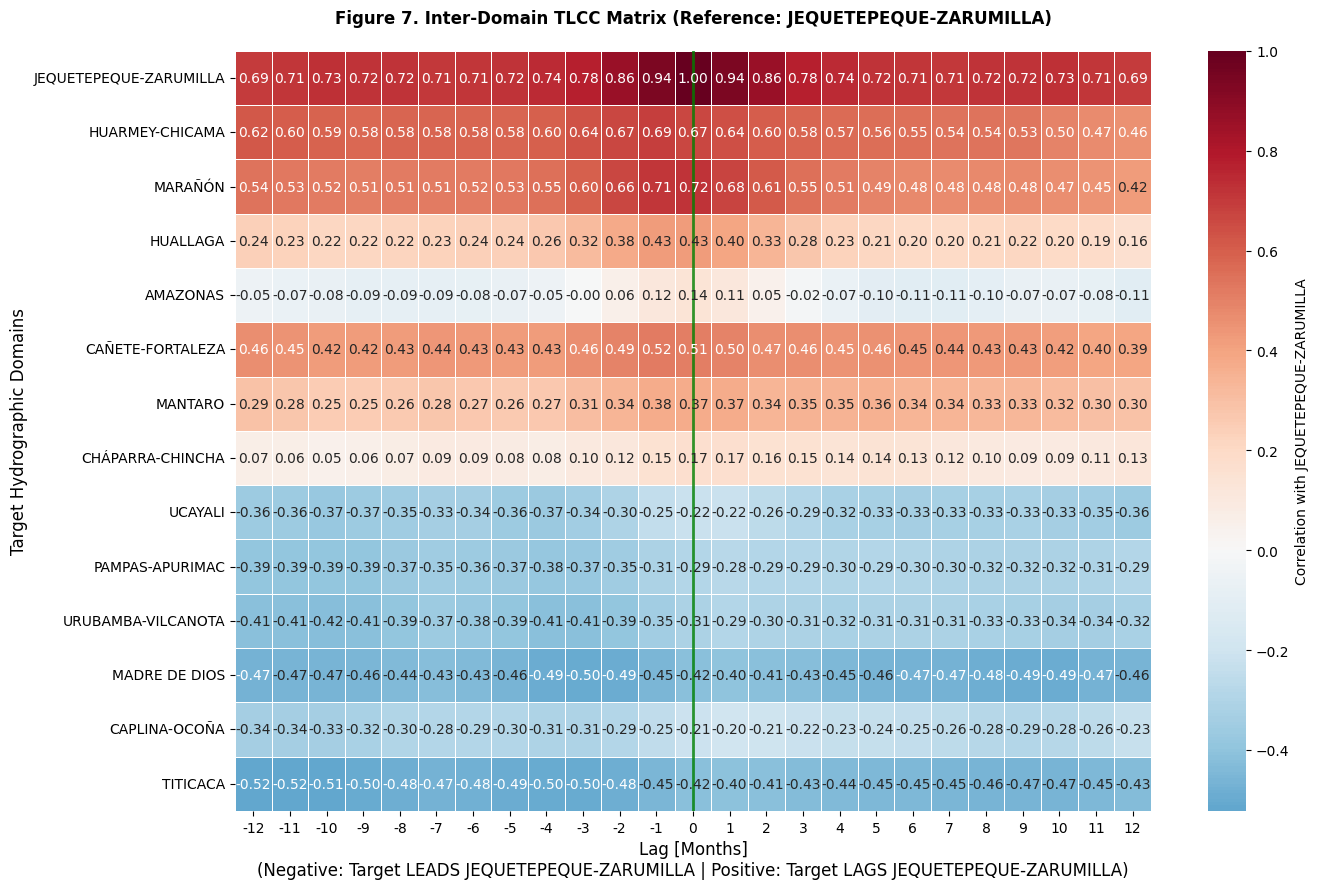

In [60]:
# 1. MANUAL CONFIGURATION: Choose your reference (Andean/Headwater)
# Try: 'MARAÑÓN', 'MANTARO', 'HUALLAGA', 'PAMPAS-APURIMAC', 'CAÑETE-FORTALEZA' or 'URUBAMBA-VILCANOTA'
REFERENCE_DOMAIN = 'JEQUETEPEQUE-ZARUMILLA'
MAX_LAG = 12  # Range of +/- 12 months

# 2. Function to compute Time-Lagged Cross-Correlation (TLCC)
def compute_tlcc(series_ref, series_target, max_lag):
    lags = np.arange(-max_lag, max_lag + 1)
    correlations = []
    for lag in lags:
        # Correlation between ref(t) and target(t + lag)
        corr = series_ref.corr(series_target.shift(-lag))
        correlations.append(corr)
    return pd.Series(correlations, index=lags)

# 3. Calculation: Correlating all domains against your selected reference
tlcc_results = {}

for domain in ordered_domain_names:
    tlcc_results[domain] = compute_tlcc(df_deseasonalized_ordered[REFERENCE_DOMAIN],
                                        df_deseasonalized_ordered[domain],
                                        MAX_LAG)

# Convert to Matrix
df_tlcc_matrix = pd.DataFrame(tlcc_results).T

# 4. Visualization: TLCC Connectivity Heatmap
plt.figure(figsize=(14, 9))
sns.heatmap(df_tlcc_matrix,
            cmap='RdBu_r',
            center=0,
            annot=True, # Activamos anotaciones para ver el valor exacto de corr
            fmt=".2f",
            linewidths=0.5,
            cbar_kws={'label': f'Correlation with {REFERENCE_DOMAIN}'})

plt.title(f'Figure 7. Inter-Domain TLCC Matrix (Reference: {REFERENCE_DOMAIN})',
          fontweight='bold', fontsize=12, pad=20)
plt.xlabel(f'Lag [Months]\n(Negative: Target LEADS {REFERENCE_DOMAIN} | Positive: Target LAGS {REFERENCE_DOMAIN})',
           fontsize=12)
plt.ylabel('Target Hydrographic Domains', fontsize=12)

# Line (Lag 0)
plt.axvline(x=MAX_LAG + 0.5, color='green', linestyle='-', linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()
plt.close()

## 5.4 Analysis of Peak Correlations and Hydrological Lags

**Scientific Synthesis: North-to-South
Hydrological Pulse**

The cross-domain connectivity analysis identifies a clear temporal gradient along the Peruvian Pacific watershed. By using JEQUETEPEQUE-ZARUMILLA as the northernmost reference, the following dynamics in the timing of water storage anomalies are observed:

- **Early Activation in the North:** A consistent -1 month lag is identified for the central-northern coastal basins (from Huarmey to Cañete) relative to Jequetepeque. This indicates that Jequetepeque is the first to record significant changes in TWS, with the signal manifesting in subsequent domains with a 1-month delay.

- **Spatio-temporal Coherence:** The stability of this 1-month delay across multiple central basins suggests a organized propagation of the climate signal, likely linked to the southward progression of sea surface temperature anomalies during El Niño Costero events.

- **Signal Attenuation and Regional Shifts:** As the analysis moves southward, the correlation strength decreases, and the synchronization eventually breaks down in the southern domains (e.g., Caplina-Ocoña). This transition confirms that the northern basins are more directly coupled to equatorial forcing, while the south follows a distinct hydrological regime.

> **Note:** These results highlight Jequetepeque's role as the "first responder" to coastal climate forcing. The 1-month lead time provides a verifiable statistical window for monitoring the arrival of extreme hydrological events across the Peruvian coast.

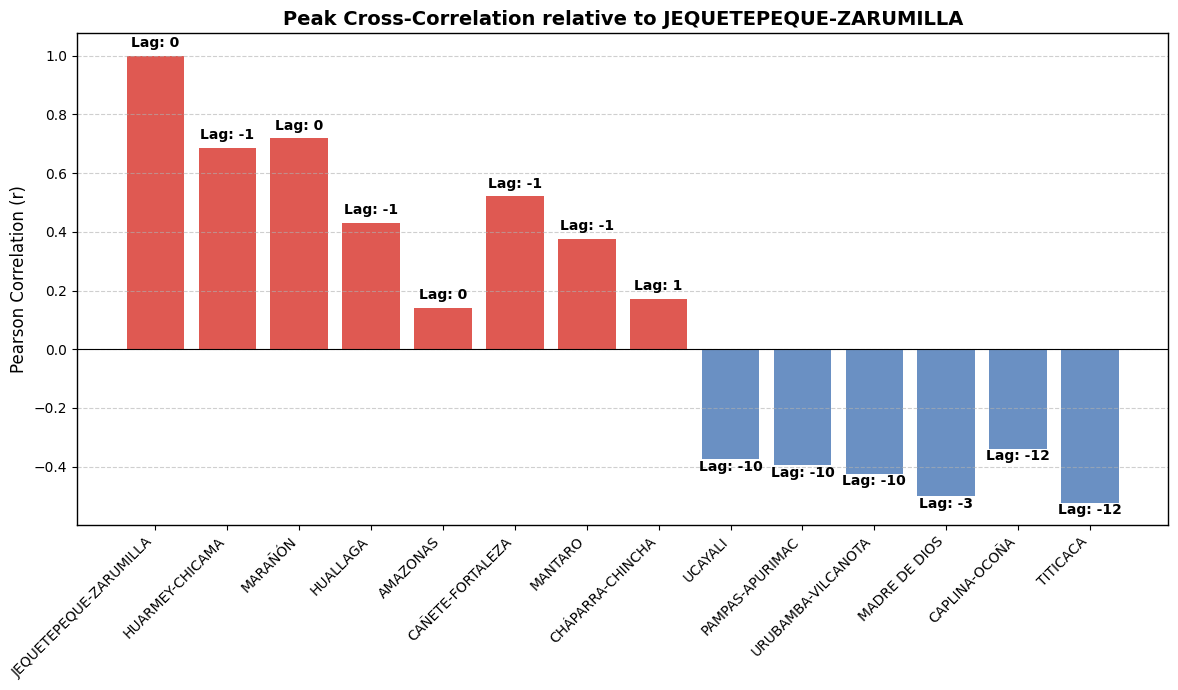

In [61]:
# Extract the Max Correlation and its corresponding Lag for each domain
peak_lags = []
max_corrs = []

for domain in ordered_domain_names:
    # Find the lag with the absolute maximum correlation
    abs_corr = df_tlcc_matrix.loc[domain].abs()
    peak_lag = abs_corr.idxmax()
    max_val = df_tlcc_matrix.loc[domain, peak_lag]

    peak_lags.append(peak_lag)
    max_corrs.append(max_val)

# Create a summary DataFrame
df_peaks = pd.DataFrame({
    'Domain': ordered_domain_names,
    'Max_Correlation': max_corrs,
    'Lag_Months': peak_lags
}).set_index('Domain')

# Visualization: Bar chart of Max Correlations with Lag annotations
plt.figure(figsize=(12, 7))
colors = ['#d73027' if c > 0 else '#4575b4' for c in df_peaks['Max_Correlation']]
bars = plt.bar(df_peaks.index, df_peaks['Max_Correlation'], color=colors, alpha=0.8)

# Add Lag labels on top of bars
for bar, lag in zip(bars, df_peaks['Lag_Months']):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (0.02 if yval > 0 else -0.05),
             f'Lag: {lag}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.axhline(0, color='black', linewidth=0.8)
plt.title(f'Peak Cross-Correlation relative to {REFERENCE_DOMAIN}', fontweight='bold', fontsize=14)
plt.ylabel('Pearson Correlation (r)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
plt.close()

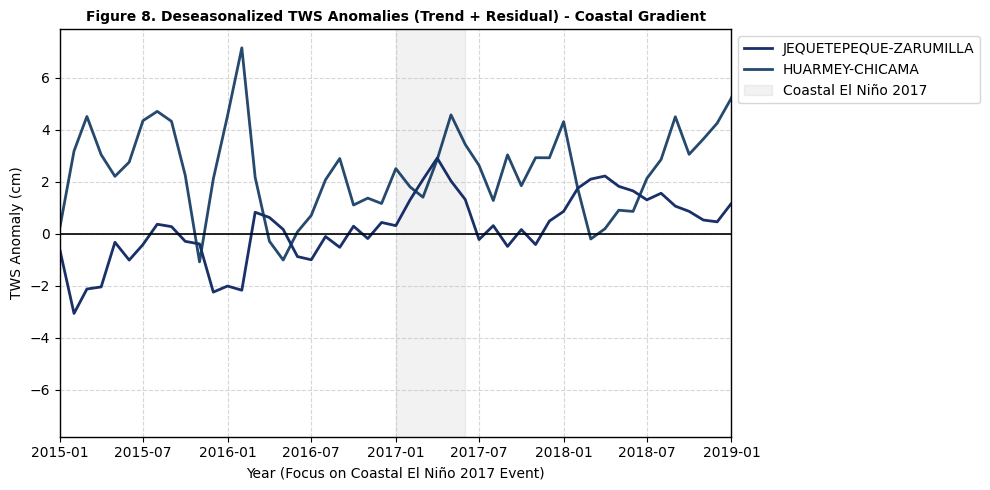

In [66]:
# Plotting the raw deseasonalized components (cm) for selected coastal Pacific domains.

# Define the coastal domains from North to South for a latitudinal comparison.
coastal_domains = [
    'JEQUETEPEQUE-ZARUMILLA',
    'HUARMEY-CHICAMA'
]

# Setup the plot with a specific figure size.
plt.figure(figsize=(10, 5))

# Assign colors from the 'batlow' colormap to the selected coastal domains.
# This ensures consistency with previous visualizations.
colors = colores_batlow[0:2]

# Loop through each selected coastal domain and plot its deseasonalized TWS anomalies.
for domain, color in zip(coastal_domains, colors):
    # Check if the domain exists in the processed DataFrame.
    if domain in df_deseasonalized_ordered.columns:
        plt.plot(df_deseasonalized_ordered.index,
                 df_deseasonalized_ordered[domain],
                 label=domain, color=color, linewidth=2, alpha=0.9)

# Add aesthetic and reference elements to the plot.
plt.axhline(0, color='black', linewidth=1.2, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Set the x-axis limits to focus on the period of the 2017 Coastal El Niño event.
plt.xlim(pd.Timestamp('2015-01-01'), pd.Timestamp('2019-01-01'))

# Set the plot title and axis labels.
plt.title('Figure 8. Deseasonalized TWS Anomalies (Trend + Residual) - Coastal Gradient',
          fontweight='bold')
plt.ylabel('TWS Anomaly (cm)')
plt.xlabel('Year (Focus on Coastal El Niño 2017 Event)')

# Add a shaded region to highlight the duration of the 2017 Coastal El Niño event.
plt.axvspan(pd.Timestamp('2017-01-01'), pd.Timestamp('2017-06-01'),
            color='gray', alpha=0.1, label='Coastal El Niño 2017')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
plt.tight_layout()
plt.show()
plt.close()

# VI. Climate Forcing: TLCC with Standardized ENSO Indices

## 6.1. Index and TWS Standardization

Transforming TWS non-seasonal components and ENSO indices (ONI & ICEN) into Z-scores to ensure unitless, comparable statistical distributions.

> **Observation:** For Jequetepeque-Zarumilla domain, during Coastal El Niño 2017, the ICEN signal clearly precedes the TWS signal, while the ONI signal appears after the TWS signal.

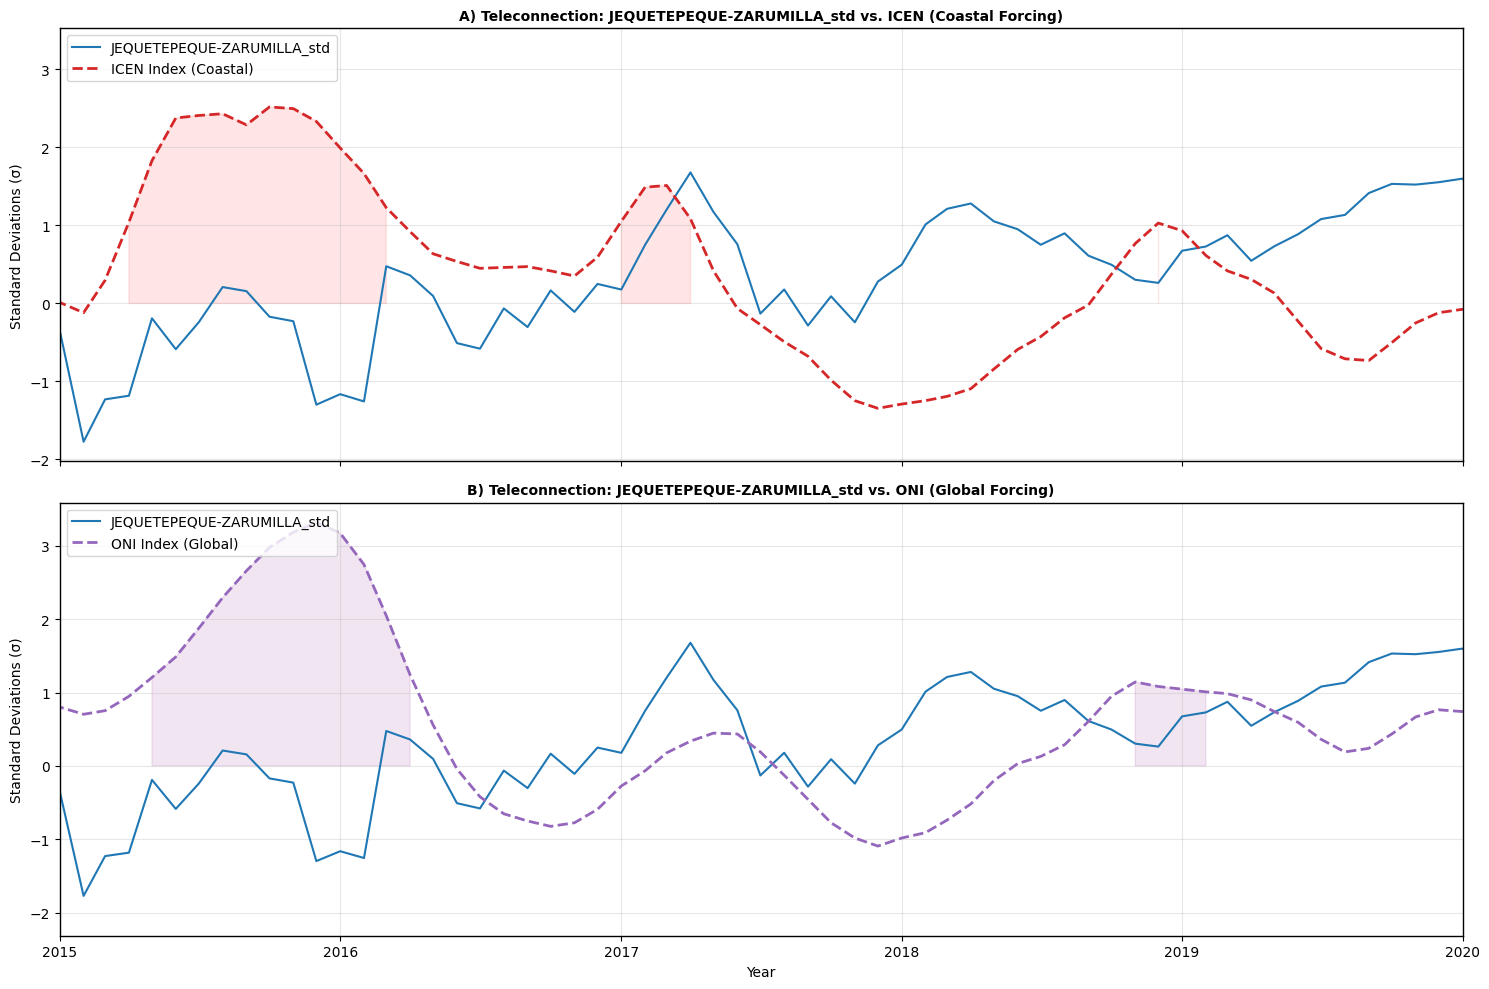

In [72]:
# Standardizing allows for a direct comparison between TWS (cm) and
# ENSO indices (°C) by placing them on a common dimensionless scale.

from sklearn.preprocessing import StandardScaler

# Initialize the Scaler
scaler = StandardScaler()

# Standardize ENSO Indices
# We ensure the indices are aligned with the TWS timeframe
df_enso_std = pd.DataFrame(index=df_oni.index)
df_enso_std['ONI_std'] = scaler.fit_transform(df_oni[['oni']])
df_enso_std['ICEN_std'] = scaler.fit_transform(df_icen[['icen']])

# Standardize TWS Deseasonalized Components (Trend + Residual)
# We apply the transformation to all hydrographic domains
df_tws_std = pd.DataFrame(index=df_deseasonalized_ordered.index)

for domain in df_deseasonalized_ordered.columns:
    series_data = df_deseasonalized_ordered[domain].values.reshape(-1, 1)
    df_tws_std[f"{domain}_std"] = scaler.fit_transform(series_data)

# Visualization: Domain Target vs. ONI vs. ICEN
TARGET_DOMAIN_STD = 'JEQUETEPEQUE-ZARUMILLA_std'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# --- PANEL 1: ICEN (Coastal El Niño) ---
ax1.plot(df_tws_std.index, df_tws_std[TARGET_DOMAIN_STD],
         label=f'{TARGET_DOMAIN_STD}', color='#1f77b4', linewidth=1.5)
ax1.plot(df_enso_std.index, df_enso_std['ICEN_std'],
         label='ICEN Index (Coastal)', color='#d62728', linewidth=2, linestyle='--')
ax1.fill_between(df_enso_std.index, 0, df_enso_std['ICEN_std'],
                 where=(df_enso_std['ICEN_std'] > 1.0), color='red', alpha=0.1)
ax1.set_title(f'A) Teleconnection: {TARGET_DOMAIN_STD} vs. ICEN (Coastal Forcing)', fontweight='bold')
ax1.set_ylabel('Standard Deviations (σ)')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# --- PANEL 2: ONI (Global El Niño) ---
ax2.plot(df_tws_std.index, df_tws_std[TARGET_DOMAIN_STD],
         label=f'{TARGET_DOMAIN_STD}', color='#1f77b4', linewidth=1.5)
ax2.plot(df_enso_std.index, df_enso_std['ONI_std'],
         label='ONI Index (Global)', color='#9467bd', linewidth=2, linestyle='--')
ax2.fill_between(df_enso_std.index, 0, df_enso_std['ONI_std'],
                 where=(df_enso_std['ONI_std'] > 1.0), color='purple', alpha=0.1)
ax2.set_title(f'B) Teleconnection: {TARGET_DOMAIN_STD} vs. ONI (Global Forcing)', fontweight='bold')
ax2.set_ylabel('Standard Deviations (σ)')
ax2.set_xlabel('Year')
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

# Zoom in on the critical 2015-2020 window
plt.xlim(pd.Timestamp('2015-01-01'), pd.Timestamp('2020-01-01'))

plt.tight_layout()
plt.show()
plt.close()

## 6.2. Teleconnection Lag Analysis

Computing the TLCC between each domain's TWS and the ONI (Global/Central Pacific) and ICEN (Coastal) indices.

**Scientific Synthesis: Oceanic-Terrestrial Coupling Efficiency**

The Cross-Correlation Function (CCF) between the ICEN (Coastal El Niño Index) and the Jequetepeque-Zarumilla TWS anomalies provides a quantitative measure of the teleconnection's timing and strength. The analysis yields a peak correlation of $r = 0.17$ at a Lag of +1 month.

- **Temporal Delay (Response Lag):** The +1 month lag indicates that the terrestrial water storage response is not instantaneous. There is a 30-day window between the manifestation of sea surface temperature anomalies and the maximum accumulation of water mass in the northern basins. This delay likely reflects the time required for atmospheric moisture transport and subsequent soil infiltration processes.

- **Coupling Strength:** While extreme events like the 2017 Coastal El Niño show high visual synchronization, the modest overall correlation ($r=0.17$) suggests that the TWS signal is influenced by a combination of factors. Beyond direct oceanic forcing, local hydrological management (e.g., reservoir operations in the Jequetepeque valley) and non-linear basin responses dampen the continuous statistical relationship over the full 2002–2025 period.

- **Comparative Forcing:** The ICEN maintains a stronger and more coherent phase relationship compared to the ONI (Global Index), reafirming that regional coastal warming is the primary, albeit episodic, driver of significant water storage shifts in Northern Peru.


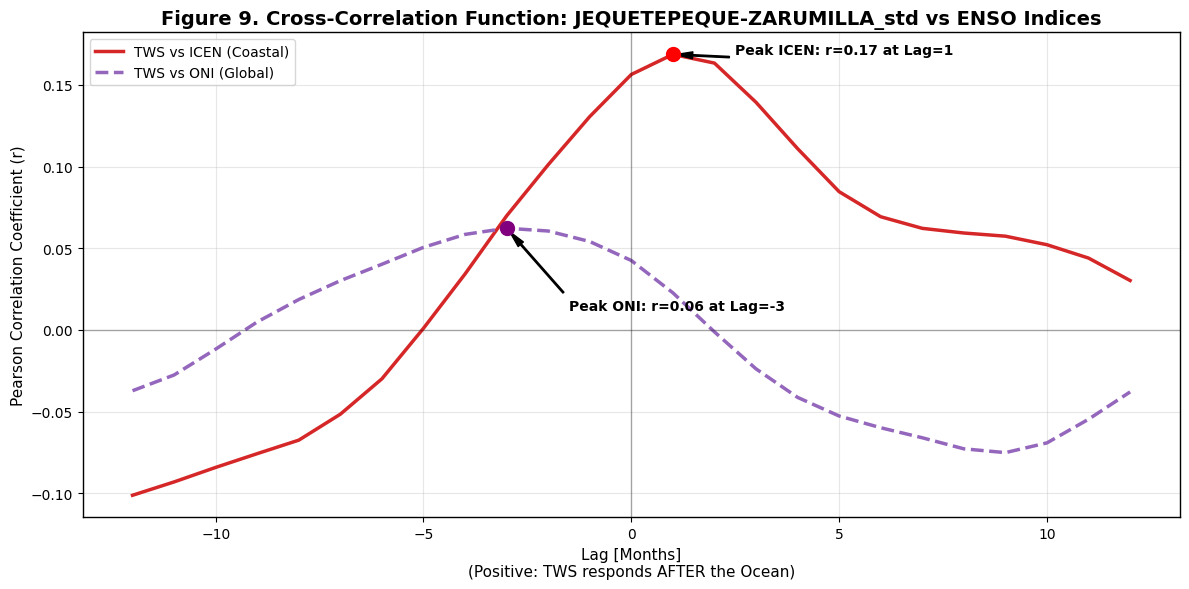

In [78]:
# This section quantifies the statistical link and temporal delay
# between oceanic anomalies and terrestrial water storage.

# Configuration for the analysis
# Change the domain for visualization sensibility,
# e.g.: 'MARAÑÓN_std', 'JEQUETEPEQUE-ZARUMILLA_std', 'AMAZONAS_std', 'CAPLINA-OCOÑA_std'
TARGET_DOMAIN_STD =  'JEQUETEPEQUE-ZARUMILLA_std'
MAX_LAG = 12

# Compute TLCC for both indices relative to the Domain
tlcc_icen = compute_tlcc(df_enso_std['ICEN_std'], df_tws_std[TARGET_DOMAIN_STD], MAX_LAG)
tlcc_oni = compute_tlcc(df_enso_std['ONI_std'], df_tws_std[TARGET_DOMAIN_STD], MAX_LAG)

# Visualization: Cross-Correlation Functions
plt.figure(figsize=(12, 6))

# Plotting ICEN (Coastal) and ONI (Global)
plt.plot(tlcc_icen.index, tlcc_icen.values, label='TWS vs ICEN (Coastal)', color='#d62728', linewidth=2.5)
plt.plot(tlcc_oni.index, tlcc_oni.values, label='TWS vs ONI (Global)', color='#9467bd', linewidth=2.5, linestyle='--')

# Automatic Peak Detection for ICEN
peak_lag_icen = tlcc_icen.idxmax()
peak_corr_icen = tlcc_icen.max()

plt.scatter(peak_lag_icen, peak_corr_icen, color='red', s=100, zorder=5)
plt.annotate(f'Peak ICEN: r={peak_corr_icen:.2f} at Lag={peak_lag_icen}',
             xy=(peak_lag_icen, peak_corr_icen),
             xytext=(peak_lag_icen + 1.5, peak_corr_icen),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontweight='bold')

# Automatic Peak Detection for ONI
peak_lag_oni = tlcc_oni.idxmax()
peak_corr_oni = tlcc_oni.max()

plt.scatter(peak_lag_oni, peak_corr_oni, color='purple', s=100, zorder=5)
plt.annotate(f'Peak ONI: r={peak_corr_oni:.2f} at Lag={peak_lag_oni}',
             xy=(peak_lag_oni, peak_corr_oni),
             xytext=(peak_lag_oni + 1.5, peak_corr_oni - 0.05), # Adjust position slightly to avoid overlap
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontweight='bold')

# Formatting Figure
plt.axvline(0, color='black', linestyle='-', alpha=0.3)
plt.axhline(0, color='black', linestyle='-', alpha=0.3)
plt.title(f'Figure 9. Cross-Correlation Function: {TARGET_DOMAIN_STD} vs ENSO Indices',
          fontweight='bold', fontsize=14)
plt.xlabel('Lag [Months]\n(Positive: TWS responds AFTER the Ocean)', fontsize=11)
plt.ylabel('Pearson Correlation Coefficient (r)', fontsize=11)
plt.legend(frameon=True, loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

## 6.3. Regional Climate Sensitivity

**Scientific Synthesis: Latitudinal Shift in Climate Drivers**

The regional sensitivity analysis reveals a complex spatial structure in how oceanic indices correlate with terrestrial water storage:

- **Northern Coastal Control:** In the North (Jequetepeque), the ICEN ($r=0.17$) shows a clearer dominance over the ONI, confirming that northern hydrology is primarily synchronized with coastal warming.

- **The Central Transition Zone:** In the Center (Cañete-Fortaleza), both indices show very low and nearly identical correlations ($0.12$ for ICEN vs $0.13$ for ONI).

- **Southern Global Teleconnection:** In the South (Caplina-Ocoña), the ONI becomes the strongest predictor ($r=0.18$), outperforming the ICEN. This highlights a shift toward global-scale Pacific forcing as we move away from the equatorial coastal zone.

> **Key Finding:** Peru's Pacific watershed exhibits a sensitivity pattern, where the extremes (North and South) have identifiable oceanic drivers, while the Center remains a transitional region with weakened teleconnections.

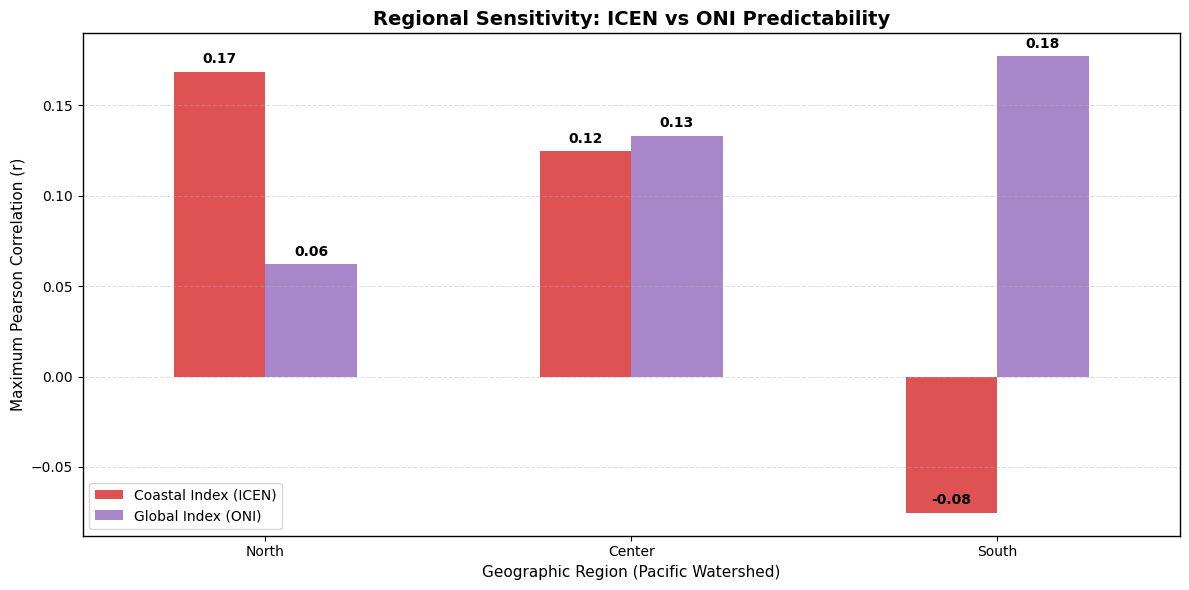

In [80]:
# Comparative evaluation of which index better explains TWS anomalies
# across the North, Center, and South of the Pacific watershed.

# Selection of representative domains for the Latitudinal Gradient
regional_targets = {
    'North': 'JEQUETEPEQUE-ZARUMILLA_std',
    'Center': 'CAÑETE-FORTALEZA_std',
    'South': 'CAPLINA-OCOÑA_std'
}

results_sensitivity = []

# Calculation Loop
for region, domain in regional_targets.items():
    if domain in df_tws_std.columns:
        # Calculate max correlation for both indices
        r_icen = compute_tlcc(df_enso_std['ICEN_std'], df_tws_std[domain], MAX_LAG).max()
        r_oni = compute_tlcc(df_enso_std['ONI_std'], df_tws_std[domain], MAX_LAG).max()

        results_sensitivity.append({
            'Region': region,
            'ICEN_r': r_icen,
            'ONI_r': r_oni
        })

df_sens = pd.DataFrame(results_sensitivity).set_index('Region')

# Visualization: Comparative Bar Chart
ax = df_sens.plot(kind='bar', figsize=(12, 6), color=['#d62728', '#9467bd'], alpha=0.8)

# Scientific Annotations
plt.title('Regional Sensitivity: ICEN vs ONI Predictability', fontweight='bold', fontsize=14)
plt.ylabel('Maximum Pearson Correlation (r)', fontsize=11)
plt.xlabel('Geographic Region (Pacific Watershed)', fontsize=11)
plt.xticks(rotation=0)
plt.legend(['Coastal Index (ICEN)', 'Global Index (ONI)'], frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Highlight the dominant index for each region
for i, p in enumerate(ax.patches):
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()

## 6.4. Extreme Event Mapping

Correlating the strongest historical lags with major El Niño (2015-2016) and Coastal El Niño (2017) events identified in the Hovmöller diagrams.

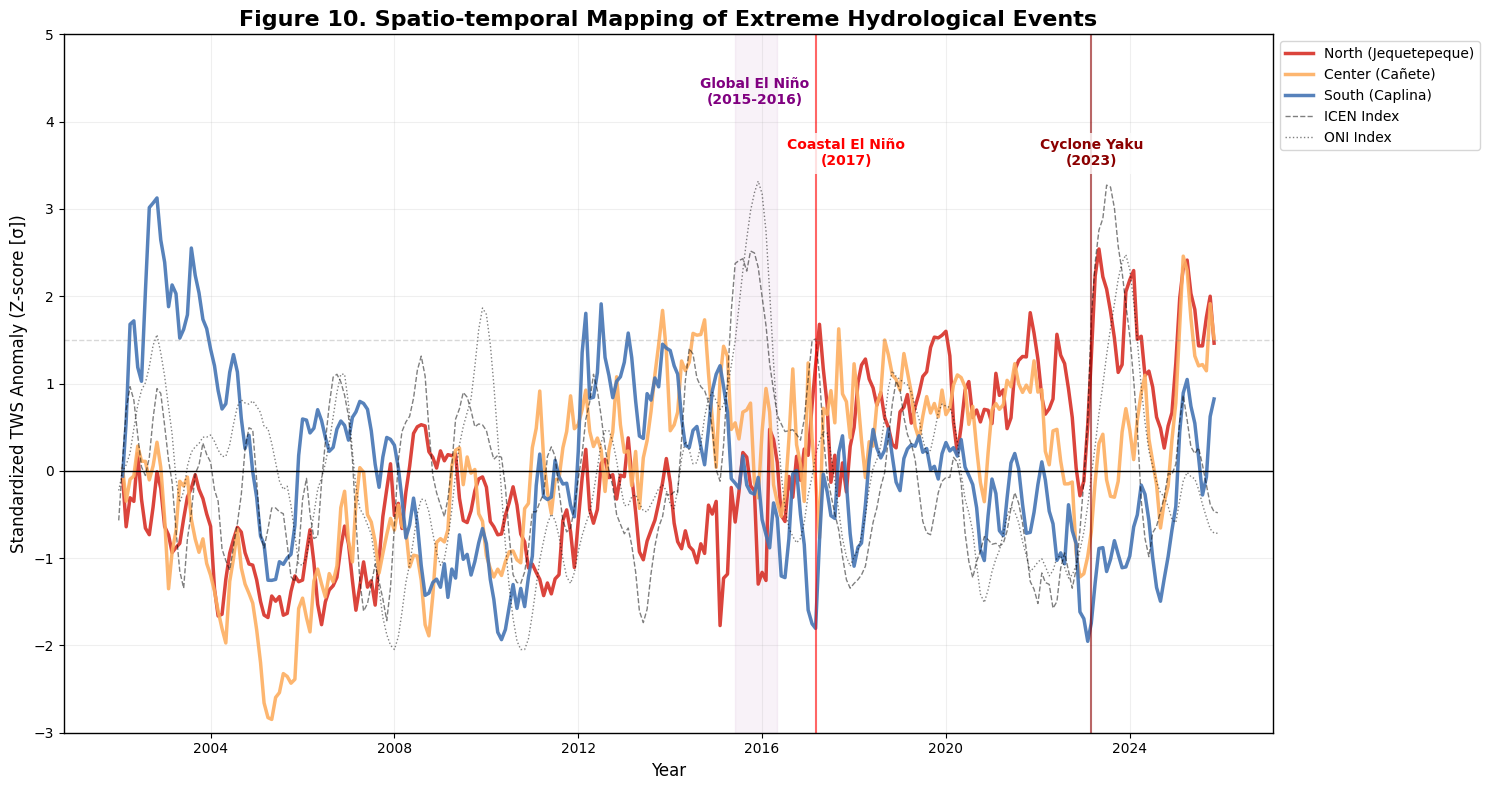

In [82]:
# Visual validation of the hydrological response during major ENSO
# events (2015-2016, 2017, 2023) across the latitudinal gradient.

# Selection of key representative domains
representative_domains = {
    'North (Jequetepeque)': 'JEQUETEPEQUE-ZARUMILLA_std',
    'Center (Cañete)': 'CAÑETE-FORTALEZA_std',
    'South (Caplina)': 'CAPLINA-OCOÑA_std'
}

plt.figure(figsize=(15, 8))

# Plot TWS Z-scores for each region
colors = ['#d73027', '#fdae61', '#4575b4'] # North: Red, Center: Orange, South: Blue
for (label, col), color in zip(representative_domains.items(), colors):
    if col in df_tws_std.columns:
        plt.plot(df_tws_std.index, df_tws_std[col], label=label, color=color, linewidth=2.5, alpha=0.9)

# Add Reference Indices (Standardized)
plt.plot(df_enso_std.index, df_enso_std['ICEN_std'], color='black', alpha=0.5, linestyle='--', label='ICEN Index')
plt.plot(df_enso_std.index, df_enso_std['ONI_std'], color='black', alpha=0.5, linestyle=':', label='ONI Index')

# Highlighting and Labeling Extreme Events
# Global El Niño 2015-2016
plt.axvspan(pd.Timestamp('2015-06-01'), pd.Timestamp('2016-05-01'), color='purple', alpha=0.05)
plt.text(pd.Timestamp('2015-11-01'), 4.2, 'Global El Niño\n(2015-2016)', color='purple',
         ha='center', fontweight='bold', fontsize=10)

# Coastal El Niño 2017
plt.axvline(pd.Timestamp('2017-03-01'), color='red', linestyle='-', linewidth=1.5, alpha=0.6)
plt.text(pd.Timestamp('2017-11-01'), 3.5, 'Coastal El Niño\n(2017)', color='red',
         ha='center', fontweight='bold', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Coastal Event 2023 (Yaku)
plt.axvline(pd.Timestamp('2023-03-01'), color='darkred', linestyle='-', linewidth=1.5, alpha=0.6)
plt.text(pd.Timestamp('2023-03-01'), 3.5, 'Cyclone Yaku\n(2023)', color='darkred',
         ha='center', fontweight='bold', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Scientific Formatting
plt.axhline(0, color='black', linewidth=1)
plt.axhline(1.5, color='gray', linestyle='--', alpha=0.3) # Extreme threshold
plt.title('Figure 10. Spatio-temporal Mapping of Extreme Hydrological Events', fontweight='bold', fontsize=16)
plt.ylabel('Standardized TWS Anomaly (Z-score [σ])', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.ylim(-3, 5)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()
plt.close()

# VII. Indices C and E Teleconnections

This section delves into the influence of the C and E indices on Terrestrial Water Storage (TWS) anomalies in Perú. The C and E indices, derived from sea surface temperature anomalies in specific oceanic regions, offer insights into different aspects of ENSO (El Niño-Southern Oscillation) variability. The C index primarily reflects central Pacific ENSO events, while the E index is associated with eastern Pacific ENSO events, often linked to Coastal El Niño phenomena.

By analyzing their teleconnections with TWS, we aim to understand the distinct hydrological responses across Peruvian hydrological domains to these different ENSO flavors. This analysis complements the previous section by introducing alternative climate drivers that are particularly relevant to the hydrology of the South American Pacific coast and the Amazon basin.

### Data downloaded from IGP (Instituto Geofísico del Perú)

**Source page:** http://met.igp.gob.pe/variabclim/indices.html

**Repository:** http://met.igp.gob.pe/datos/ecindex_ersstv5.txt


## 7.1 ENSO Indices (C & E)

In [83]:
# --- Loading ENSO Indices (C & E)---

# Define internal paths within the cloned repository
# REPO_NAME ya fue definido en la celda de clonación anterior
CEINDEX_PATH = os.path.join(REPO_NAME, "data/enso/ecindex_ersstv5.csv")

# Processing Indices (C & E)
if os.path.exists(CEINDEX_PATH):
    df_enso = pd.read_csv(CEINDEX_PATH, index_col='time')
    df_enso.index = pd.to_datetime(df_enso.index)
    print("Status: C and E index loaded successfully from local repository.")
else:
    print(f"Error: CE index file not found at {CEINDEX_PATH}")

Status: C and E index loaded successfully from local repository.


In [ ]:
# --- Visualizing C & E index (orignal data)---

# Filter the DataFrame for the specified time range
start_date = '2002-01-01'
end_date = '2025-12-01'
df_filtered = df_enso.loc[start_date:end_date]

# Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot C_index on the first subplot
axes[0].plot(df_filtered.index, df_filtered['C_index'], label='C_index', color='blue', linewidth=1.5)
axes[0].set_title('C_index Time Series (2002-2025)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('C_index')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Plot E_index on the second subplot
axes[1].plot(df_filtered.index, df_filtered['E_index'], label='E_index', color='red', linewidth=1.5)
axes[1].set_title('E_index Time Series (2002-2025)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('E_index')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close()

In [ ]:
##--- Check and Imputation for existing NaN ---
# Check for existing NaN values in df_enso
print("NaNs in df_enso before imputation:")
print(df_enso.isnull().sum())

# Impute NaN values using quadratic interpolation
# This method fits a quadratic polynomial to the non-NaN values around the NaN to estimate the missing value.
df_enso_curated = df_enso.interpolate(method='quadratic')

# Verify that NaNs have been handled
print("\nNaNs in df_enso_curated after imputation:")
print(df_enso_curated.isnull().sum())

# Display the head of the curated DataFrame
print("\nHead of the curated DataFrame (df_enso_curated):")
display(df_enso_curated.head())

# Display the tail of the curated DataFrame
print("\nTail of the curated DataFrame (df_enso_curated):")
display(df_enso_curated.tail())

# Display general information about the DataFrame
print("\nInfo of the curated DataFrame (df_enso_curated):")
df_enso_curated.info()

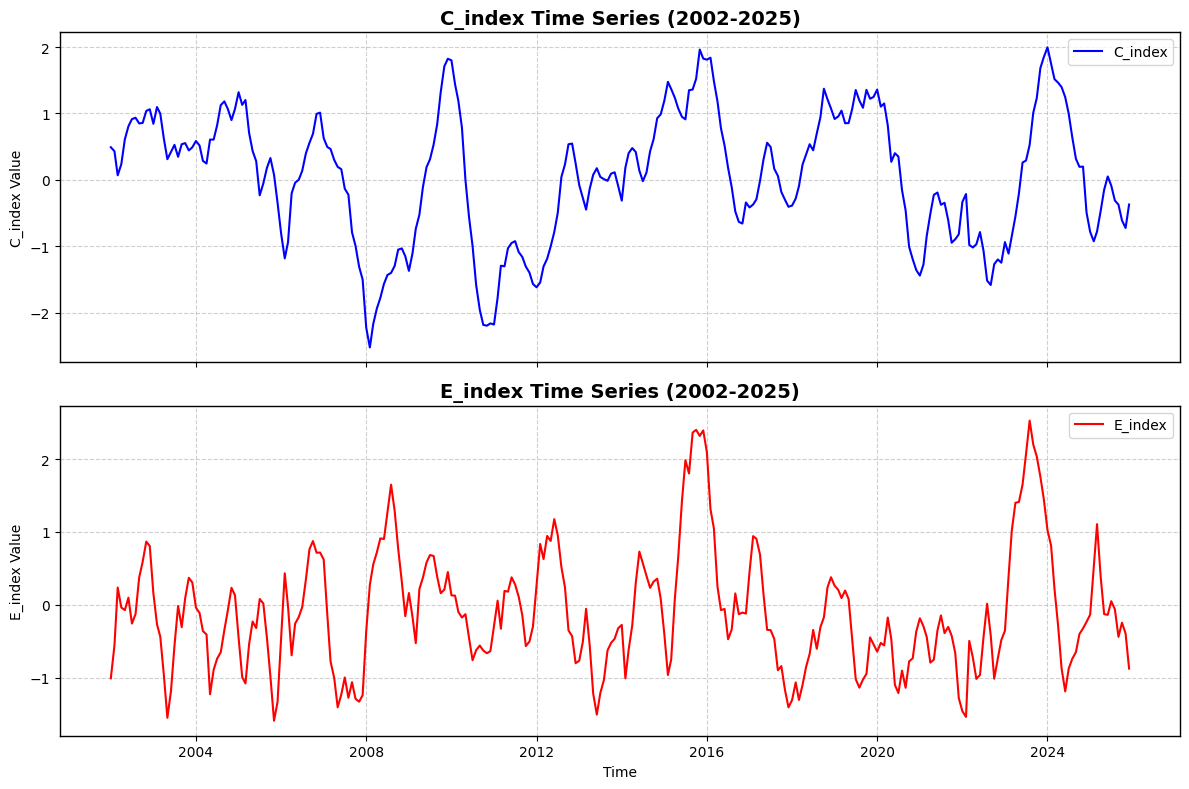

In [86]:
# --- Visualizing C & E index (curated data)---

# Filter the DataFrame for the specified time range
start_date = '2002-01-01'
end_date = '2025-12-01'
df_filtered = df_enso_curated.loc[start_date:end_date]

# Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot C_index on the first subplot
axes[0].plot(df_filtered.index, df_filtered['C_index'], label='C_index', color='blue', linewidth=1.5)
axes[0].set_title('C_index Time Series (2002-2025)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('C_index Value')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Plot E_index on the second subplot
axes[1].plot(df_filtered.index, df_filtered['E_index'], label='E_index', color='red', linewidth=1.5)
axes[1].set_title('E_index Time Series (2002-2025)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('E_index Value')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close()

In [ ]:
# --- (3-month) Moving Average for smoothing---

# Apply centered quarterly (3-month) moving average for smoothing
print("Status: Applying centered quarterly moving average to df_enso_curated...")
df_enso_smoothed = df_enso_curated.rolling(window=3, center=True).mean()
print("[SUCCESS] df_enso_curated smoothed with centered quarterly moving average.")

print(f"\nDataFrame shape after smoothing: {df_enso_smoothed.shape}")
print("Head of the smoothed DataFrame (df_enso_smoothed):")
display(df_enso_smoothed.head())
print("Tail of the smoothed DataFrame (df_enso_smoothed):")
display(df_enso_smoothed.tail())

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# --- Additive Decomposition for C and E index---

# Drop NaN values introduced by the centered moving average to ensure decomposition works correctly
df_enso_clean = df_enso_smoothed.dropna()

# --- Additive Decomposition for C_index ---
print("Status: Performing additive decomposition for C_index...")
result_cindex = seasonal_decompose(df_enso_clean['C_index'], model='additive', period=12, extrapolate_trend='freq')
df_cindex_seasonal = result_cindex.seasonal.to_frame(name='C_index_seasonal')
df_cindex_deseasonal = (result_cindex.trend + result_cindex.resid).to_frame(name='C_index_deseasonal')
print("[SUCCESS] C_index decomposition completed.")

# --- Additive Decomposition for E_index ---
print("\nStatus: Performing additive decomposition for E_index...")
result_eindex = seasonal_decompose(df_enso_clean['E_index'], model='additive', period=12, extrapolate_trend='freq')
df_eindex_seasonal = result_eindex.seasonal.to_frame(name='E_index_seasonal')
df_eindex_deseasonal = (result_eindex.trend + result_eindex.resid).to_frame(name='E_index_deseasonal')
print("[SUCCESS] E_index decomposition completed.")

print("\n--- C_index Seasonal (Head) ---")
display(df_cindex_seasonal.head())
print("\n--- C_index Deseasonal (Head) ---")
display(df_cindex_deseasonal.head())
print("\n--- E_index Seasonal (Head) ---")
display(df_eindex_seasonal.head())
print("\n--- E_index Deseasonal (Head) ---")
display(df_eindex_deseasonal.head())

## 7.2 Seasonal Component C & E Index Serie

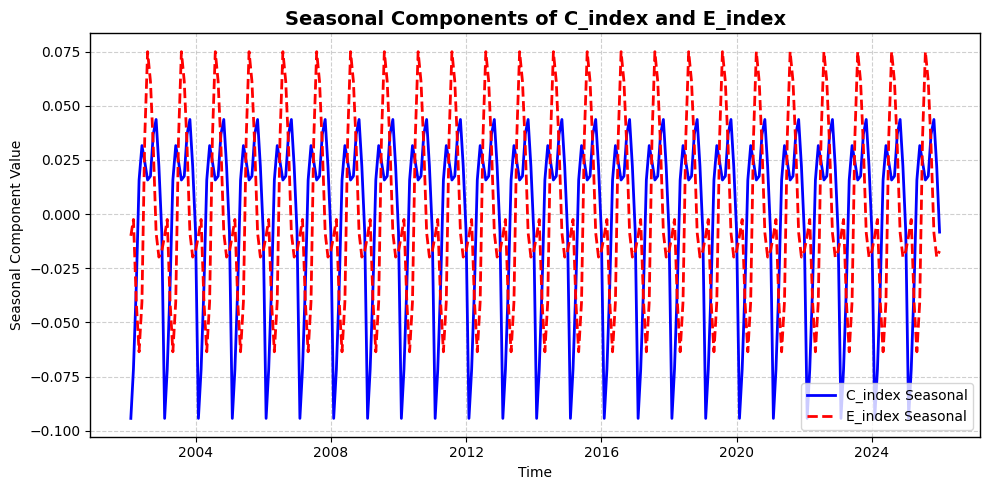

In [89]:
# C & E Index Seasonal Component
plt.figure(figsize=(10, 5))

# Plot C_index Seasonal Component
plt.plot(df_cindex_seasonal.index, df_cindex_seasonal['C_index_seasonal'], label='C_index Seasonal', color='blue', linewidth=2)

# Plot E_index Seasonal Component
plt.plot(df_eindex_seasonal.index, df_eindex_seasonal['E_index_seasonal'], label='E_index Seasonal', color='red', linewidth=2, linestyle='--')

plt.title('Seasonal Components of C_index and E_index', fontsize=14, fontweight='bold')
plt.xlabel('Time')
plt.ylabel('Seasonal Component Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 7.3 Deseasonalized Component C & E Index


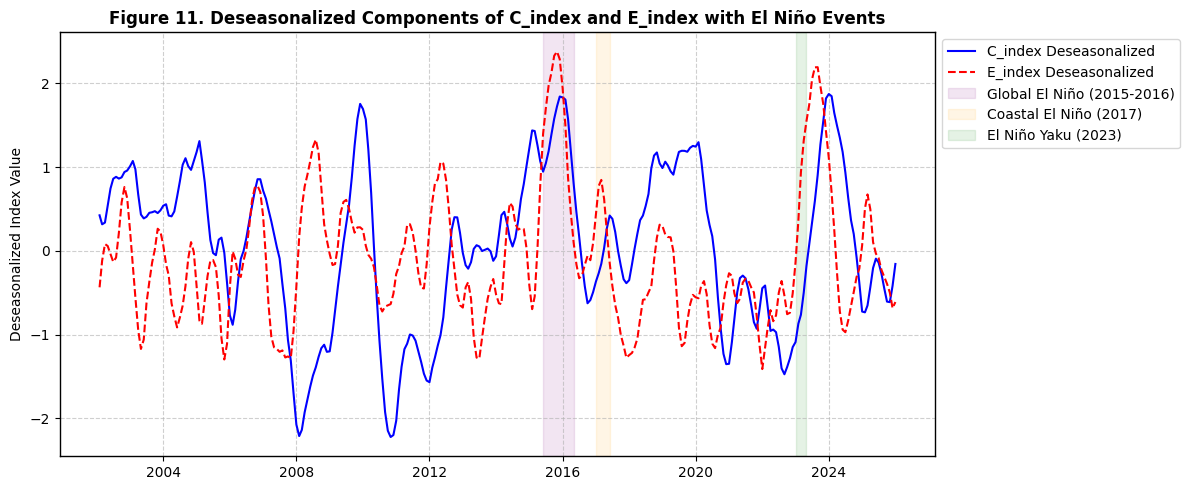

In [93]:
# C & E Index Deseasonalized Component
plt.figure(figsize=(12, 5))

# Plot C_index Deseasonalized Component
plt.plot(df_cindex_deseasonal.index, df_cindex_deseasonal['C_index_deseasonal'], label='C_index Deseasonalized', color='blue', linewidth=1.5)

# Plot E_index Deseasonalized Component
plt.plot(df_eindex_deseasonal.index, df_eindex_deseasonal['E_index_deseasonal'], label='E_index Deseasonalized', color='red', linewidth=1.5, linestyle='--')

# Shade El Niño events
# Global El Niño 2015-2016
plt.axvspan(pd.Timestamp('2015-06-01'), pd.Timestamp('2016-05-01'), color='purple', alpha=0.1, label='Global El Niño (2015-2016)')

# Coastal El Niño 2017
plt.axvspan(pd.Timestamp('2017-01-01'), pd.Timestamp('2017-06-01'), color='orange', alpha=0.1, label='Coastal El Niño (2017)')

# El Niño Yaku 2023
plt.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2023-05-01'), color='green', alpha=0.1, label='El Niño Yaku (2023)')

plt.title('Figure 11. Deseasonalized Components of C_index and E_index with El Niño Events', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.ylabel('Deseasonalized Index Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
plt.tight_layout()
plt.show()
plt.close()

## 7.4 Hovmöller Diagram


/tmp/ipykernel_19454/2945122621.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap


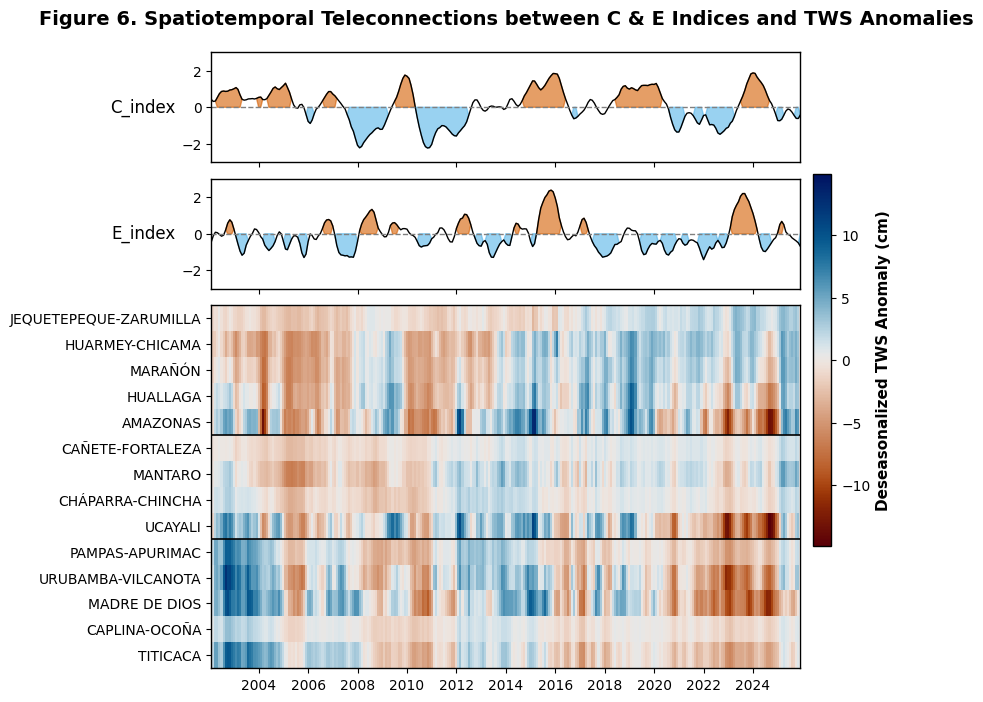

In [95]:
# --- MULTI-PANEL HOVMÖLLER DIAGRAM (C & E Indices + TWS) ---
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import cmcrameri.cm as cmc

# --- PREPARING TWS DATA (DESEASONALIZED) ---
# Reusing data already prepared in Section 5.2
# ordered_domain_names, df_deseasonalized_ordered, data_matrix, fechas_tws, dominios
# (Assuming these variables are still in the kernel from previous runs)

# Set symmetric color limits based on the maximum anomaly
vmax = np.nanmax(np.abs(data_matrix))
vmin = -vmax

# --- PREPARING C & E INDEX DATA ---
# Make sure C and E indices are aligned with TWS timeframe
common_time_index = df_deseasonalized_ordered.index.intersection(df_cindex_deseasonal.index)

df_cindex_aligned = df_cindex_deseasonal.loc[common_time_index, 'C_index_deseasonal']
df_eindex_aligned = df_eindex_deseasonal.loc[common_time_index, 'E_index_deseasonal']

# --- FIGURE CONSTRUCTION (MULTI-PANEL) ---
fig = plt.figure(figsize=(8, 8)) # Adjusting size for manuscript
gs = gridspec.GridSpec(5, 1, height_ratios=[1, 1, 1, 1, 1], hspace=0.15)

# PANEL A: C_INDEX
ax_cindex = fig.add_subplot(gs[0])
ax_cindex.plot(df_cindex_aligned.index, df_cindex_aligned, color='black', linewidth=1)
# Highlight positive/negative anomalies (e.g., >0.5 or <-0.5 for generic thresholds)
ax_cindex.fill_between(df_cindex_aligned.index, df_cindex_aligned, 0,
                       where=(df_cindex_aligned >= 0.5), color='#D55E00', alpha=0.6, interpolate=True)
ax_cindex.fill_between(df_cindex_aligned.index, df_cindex_aligned, 0,
                       where=(df_cindex_aligned <= -0.5), color='#56B4E9', alpha=0.6, interpolate=True)
ax_cindex.axhline(0, color='gray', linestyle='--', linewidth=1.0)
ax_cindex.set_ylabel('C_index', rotation=0, ha='right', va='center', fontsize=12)
ax_cindex.set_ylim(-3, 3) # Consistent y-limits for ENSO indices
ax_cindex.tick_params(axis='x', labelbottom=False)
ax_cindex.set_title('Figure 6. Spatiotemporal Teleconnections between C & E Indices and TWS Anomalies',
                    fontsize=14, fontweight='bold', pad=20, loc='center') # Set suptitle here

# PANEL B: E_INDEX
ax_eindex = fig.add_subplot(gs[1])
ax_eindex.plot(df_eindex_aligned.index, df_eindex_aligned, color='black', linewidth=1)
# Highlight positive/negative anomalies
ax_eindex.fill_between(df_eindex_aligned.index, df_eindex_aligned, 0,
                       where=(df_eindex_aligned >= 0.5), color='#D55E00', alpha=0.6, interpolate=True)
ax_eindex.fill_between(df_eindex_aligned.index, df_eindex_aligned, 0,
                       where=(df_eindex_aligned <= -0.5), color='#56B4E9', alpha=0.6, interpolate=True)
ax_eindex.axhline(0, color='gray', linestyle='--', linewidth=1.0)
ax_eindex.set_ylabel('E_index', rotation=0, ha='right', va='center', fontsize=12)
ax_eindex.set_ylim(-3, 3)
ax_eindex.tick_params(axis='x', labelbottom=False)

# PANEL C: TWS HOVMÖLLER HEATMAP
ax_tws = fig.add_subplot(gs[2:])
# Ensure fechas_tws is filtered to common_time_index as well if data_matrix is not yet aligned
# For simplicity, assuming data_matrix and fechas_tws already reflect the time range consistent with common_time_index
# or that common_time_index covers the full range of fechas_tws
mesh = ax_tws.pcolormesh(fechas_tws, np.arange(len(dominios)), data_matrix,
                         cmap=cmc.vik_r, vmin=vmin, vmax=vmax, shading='nearest')

ax_tws.set_yticks(np.arange(len(dominios)))
ax_tws.set_yticklabels(dominios, fontsize=10)
ax_tws.invert_yaxis()

# Regional delimiters (assuming these are still valid based on ordered_domain_names)
ax_tws.axhline(4.5, color='black', linewidth=1.2, linestyle='-') # North-Central boundary
ax_tws.axhline(8.5, color='black', linewidth=1.2, linestyle='-') # Central-South boundary

# --- TEMPORAL ALIGNMENT ---
# Setting consistent limits for all panels
start_date = common_time_index.min()
end_date = common_time_index.max()

for ax in [ax_cindex, ax_eindex, ax_tws]:
    ax.set_xlim(start_date, end_date)

ax_tws.xaxis.set_major_locator(mdates.YearLocator(2)) # Every 2 years
ax_tws.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(fontsize=10)
ax_tws.set_xlabel('', fontsize=12)

# Integrated Colorbar
cbar = fig.colorbar(mesh, ax=[ax_cindex, ax_eindex, ax_tws], orientation='vertical', fraction=0.03, pad=0.02)
cbar.set_label('Deseasonalized TWS Anomaly (cm)', fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()
plt.close()

## 7.5 Standarization of data

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Standardize C_index_deseasonal
# First, align index with df_deseasonalized_ordered_clean to ensure consistent time steps
common_index_for_std = df_cindex_deseasonal.index.intersection(df_deseasonalized_ordered.index)
c_index_deseasonal_aligned = df_cindex_deseasonal.loc[common_index_for_std, ['C_index_deseasonal']]

c_index_deseasonal_std = pd.DataFrame(
    scaler.fit_transform(c_index_deseasonal_aligned),
    index=c_index_deseasonal_aligned.index,
    columns=['C_index_deseasonal_std']
)

# Standardize E_index_deseasonal
e_index_deseasonal_aligned = df_eindex_deseasonal.loc[common_index_for_std, ['E_index_deseasonal']]

e_index_deseasonal_std = pd.DataFrame(
    scaler.fit_transform(e_index_deseasonal_aligned),
    index=e_index_deseasonal_aligned.index,
    columns=['E_index_deseasonal_std']
)


# Standardize df_deseasonalized_ordered (all domains)
# Initialize the DataFrame with the common_index_for_std to ensure correct length
df_deseasonalized_ordered_std = pd.DataFrame(index=common_index_for_std)
for domain in df_deseasonalized_ordered.columns:
    series_data = df_deseasonalized_ordered.loc[common_index_for_std, domain].values.reshape(-1, 1)
    df_deseasonalized_ordered_std[f"{domain}_std"] = scaler.fit_transform(series_data)

print("Status: Deseasonalized C_index, E_index and TWS domains standardized successfully.")
print("Head of standardized C_index:")
display(c_index_deseasonal_std.head())
print("Head of standardized E_index:")
display(e_index_deseasonal_std.head())
print("Head of standardized TWS (MARAÑÓN):")
display(df_deseasonalized_ordered_std['MARAÑÓN_std'].head())

## 7.6 TLCC: C_Index vs. TWS (Deseasonalized)


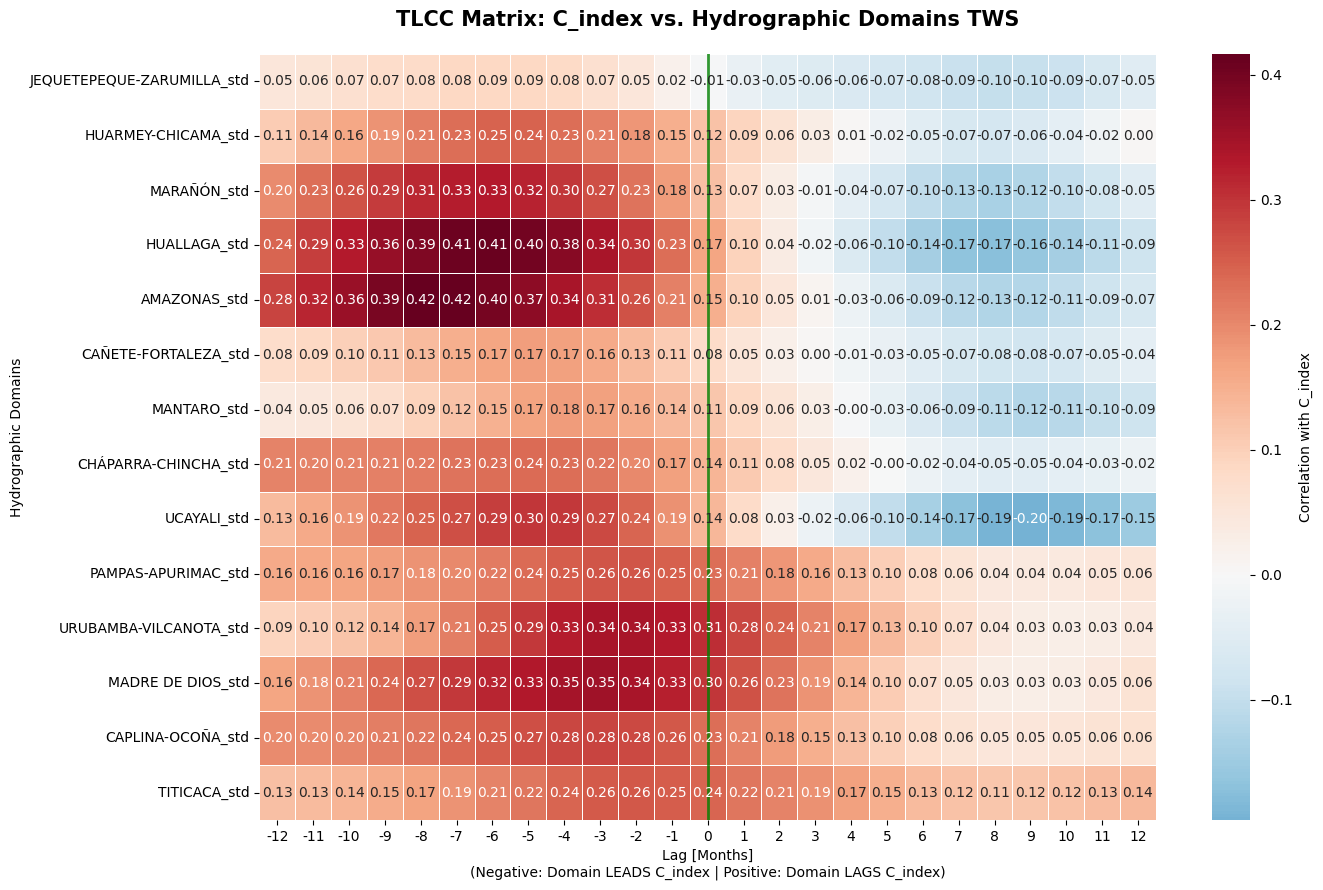

In [97]:
# Configuration: Max Lag for correlation analysis

max_lag = 12

# Ensure `compute_tlcc` function is available (defined in cell QXwYVGMNxBvH)
def compute_tlcc(series_ref, series_target, max_lag):
    lags = np.arange(-max_lag, max_lag + 1)
    correlations = []
    for lag in lags:
        # Correlation between ref(t) and target(t + lag)
        corr = series_ref.corr(series_target.shift(-lag))
        correlations.append(corr)
    return pd.Series(correlations, index=lags)

# Calculation: Correlating C_index_deseasonal with all hydrographic domains
tlcc_cindex_results = {}

# Use the already standardized series and dataframe
cindex_ref_series = c_index_deseasonal_std['C_index_deseasonal_std']

for domain_col in df_deseasonalized_ordered_std.columns:
    target_series = df_deseasonalized_ordered_std[domain_col]
    tlcc_cindex_results[domain_col] = compute_tlcc(cindex_ref_series, target_series, MAX_LAG)

# Convert to Matrix
df_tlcc_cindex_matrix = pd.DataFrame(tlcc_cindex_results).T

# Visualization: TLCC Connectivity Heatmap
plt.figure(figsize=(14, 9))
sns.heatmap(df_tlcc_cindex_matrix,
            cmap='RdBu_r',
            center=0,
            annot=True, # Display exact correlation values
            fmt=".2f",
            linewidths=0.5,
            cbar_kws={'label': 'Correlation with C_index'})

# Formatting Figure
plt.title('TLCC Matrix: C_index vs. Hydrographic Domains TWS',
          fontweight='bold',fontsize=15, pad=20)
plt.xlabel('Lag [Months]\n(Negative: Domain LEADS C_index | Positive: Domain LAGS C_index)')
plt.ylabel('Hydrographic Domains')

# Line for synchronicity (Lag 0)
plt.axvline(x=MAX_LAG + 0.5, color='green', linestyle='-', linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()
plt.close()

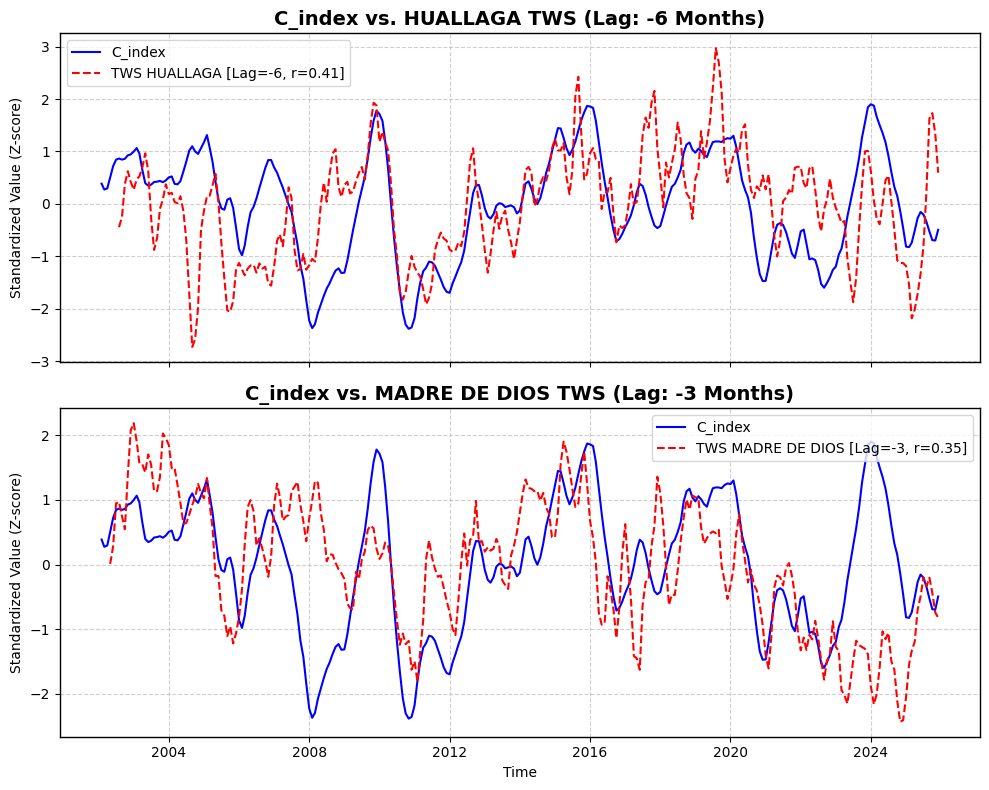

In [98]:
# --- User Configuration ---
# Define northern and southern domains and their desired lags
northern_domain = 'HUALLAGA'
southern_domain = 'MADRE DE DIOS'

manual_lag_north = -6 # Current lag for northern domain (months)
manual_lag_south = -3 # Current lag for southern domain (months)

# --- Data Selection ---
c_index_std_series = c_index_deseasonal_std['C_index_deseasonal_std']

# --- Create Subplots ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Plot for Northern Domain --- #
tws_northern_std_series = df_deseasonalized_ordered_std[f'{northern_domain}_std']
shifted_tws_northern_std = tws_northern_std_series.shift(-manual_lag_north) # Shift TWS

# Align series for correlation and plotting
common_index_north = c_index_std_series.index.intersection(shifted_tws_northern_std.index)

c_index_final_north = c_index_std_series.loc[common_index_north]
shifted_tws_final_north = shifted_tws_northern_std.loc[common_index_north]

# Retrieve correlation from pre-computed matrix
correlation_north = df_tlcc_cindex_matrix.loc[f'{northern_domain}_std', manual_lag_north]

# Plotting
axes[0].plot(c_index_final_north.index, c_index_final_north,
             label='C_index', color='blue', linewidth=1.5)
axes[0].plot(shifted_tws_final_north.index, shifted_tws_final_north,
             label=f'TWS {northern_domain} [Lag={manual_lag_north}, r={correlation_north:.2f}]',
             color='red', linewidth=1.5, linestyle='--')

axes[0].set_title(f'C_index vs. {northern_domain} TWS (Lag: {manual_lag_north} Months)',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Standardized Value (Z-score)')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# --- Plot for Southern Domain --- #
tws_southern_std_series = df_deseasonalized_ordered_std[f'{southern_domain}_std']
shifted_tws_southern_std = tws_southern_std_series.shift(-manual_lag_south) # Shift TWS

# Align series for correlation and plotting
common_index_south = c_index_std_series.index.intersection(shifted_tws_southern_std.index)

c_index_final_south = c_index_std_series.loc[common_index_south]
shifted_tws_final_south = shifted_tws_southern_std.loc[common_index_south]

# Retrieve correlation from pre-computed matrix
correlation_south = df_tlcc_cindex_matrix.loc[f'{southern_domain}_std', manual_lag_south]

# Plotting
axes[1].plot(c_index_final_south.index, c_index_final_south,
             label='C_index', color='blue', linewidth=1.5)
axes[1].plot(shifted_tws_final_south.index, shifted_tws_final_south,
             label=f'TWS {southern_domain} [Lag={manual_lag_south}, r={correlation_south:.2f}]',
             color='red', linewidth=1.5, linestyle='--')

axes[1].set_title(f'C_index vs. {southern_domain} TWS (Lag: {manual_lag_south} Months)',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Standardized Value (Z-score)')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close()

## 7.7 TLCC: E_Index vs. TWS (Deseasonalized)

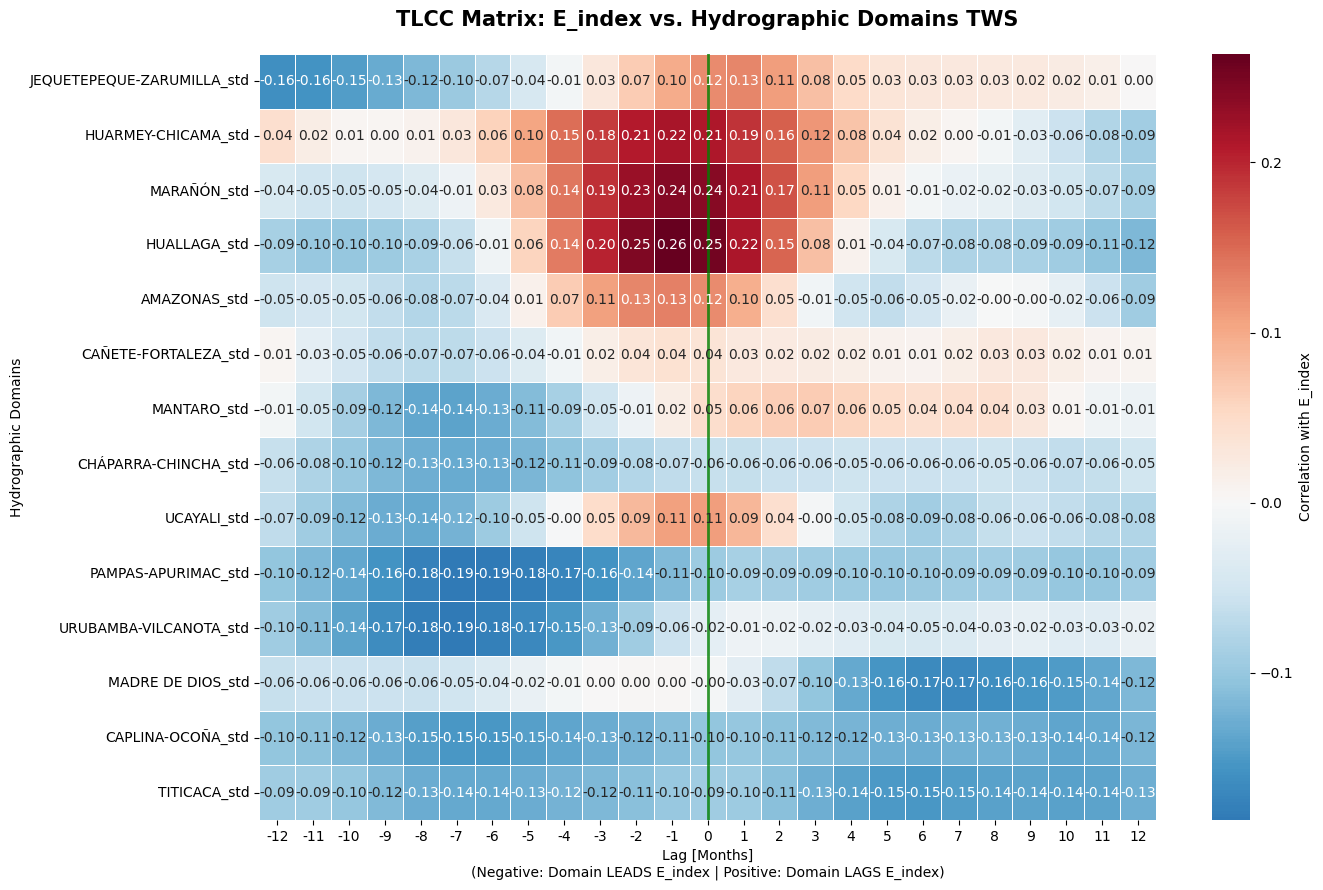

In [100]:
# Configuration: Max Lag for correlation analysis
max_lag = 12

# Ensure `compute_tlcc` function is available (defined earlier in the notebook)
def compute_tlcc(series_ref, series_target, max_lag):
    lags = np.arange(-max_lag, max_lag + 1)
    correlations = []
    for lag in lags:
        # Correlation between ref(t) and target(t + lag)
        corr = series_ref.corr(series_target.shift(-lag))
        correlations.append(corr)
    return pd.Series(correlations, index=lags)

# Calculation: Correlating E_index_deseasonal with all hydrographic domains
tlcc_eindex_results = {}

# Use the already standardized series and dataframe
eindex_ref_series = e_index_deseasonal_std['E_index_deseasonal_std']

for domain_col in df_deseasonalized_ordered_std.columns:
    target_series = df_deseasonalized_ordered_std[domain_col]
    tlcc_eindex_results[domain_col] = compute_tlcc(eindex_ref_series, target_series, MAX_LAG)

# Convert to Matrix
df_tlcc_eindex_matrix = pd.DataFrame(tlcc_eindex_results).T

# Visualization: TLCC Connectivity Heatmap
plt.figure(figsize=(14, 9))
sns.heatmap(df_tlcc_eindex_matrix,
            cmap='RdBu_r',
            center=0,
            annot=True, # Display exact correlation values
            fmt=".2f",
            linewidths=0.5,
            cbar_kws={'label': 'Correlation with E_index'})

# Formatting Figure
plt.title('TLCC Matrix: E_index vs. Hydrographic Domains TWS',
          fontweight='bold',fontsize=15, pad=20)
plt.xlabel('Lag [Months]\n(Negative: Domain LEADS E_index | Positive: Domain LAGS E_index)')
plt.ylabel('Hydrographic Domains')

# Line for synchronicity (Lag 0)
plt.axvline(x=MAX_LAG + 0.5, color='green', linestyle='-', linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()
plt.close()

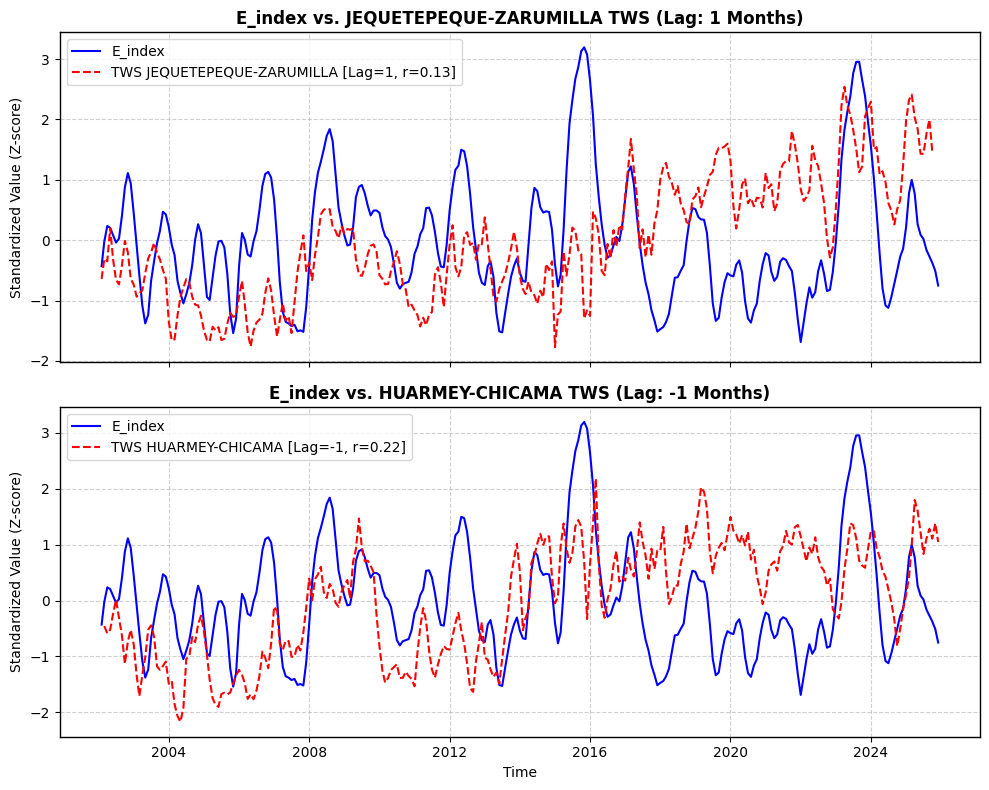

In [104]:
# --- User Configuration ---
# Define northern and southern domains and their desired lags
northern_domain = 'JEQUETEPEQUE-ZARUMILLA'
southern_domain = 'HUARMEY-CHICAMA'

manual_lag_north = 1  # Current lag for northern domain (months)
manual_lag_south = -1 # Current lag for southern domain (months)

# --- Data Selection ---
e_index_std_series = e_index_deseasonal_std['E_index_deseasonal_std']

# --- Create Subplots ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Plot for Northern Domain --- #
tws_northern_std_series = df_deseasonalized_ordered_std[f'{northern_domain}_std']
shifted_tws_northern_std = tws_northern_std_series.shift(-manual_lag_north) # Shift TWS

# Align series for correlation and plotting
common_index_north = e_index_std_series.index.intersection(shifted_tws_northern_std.index)

e_index_final_north = e_index_std_series.loc[common_index_north]
shifted_tws_final_north = shifted_tws_northern_std.loc[common_index_north]

# Retrieve correlation from pre-computed matrix
# Make sure the index of df_tlcc_eindex_matrix matches the domain name used here.
correlation_north = df_tlcc_eindex_matrix.loc[f'{northern_domain}_std', manual_lag_north]

# Plotting
axes[0].plot(e_index_final_north.index, e_index_final_north,
             label='E_index', color='blue', linewidth=1.5)
axes[0].plot(shifted_tws_final_north.index, shifted_tws_final_north,
             label=f'TWS {northern_domain} [Lag={manual_lag_north}, r={correlation_north:.2f}]',
             color='red', linewidth=1.5, linestyle='--')

axes[0].set_title(f'E_index vs. {northern_domain} TWS (Lag: {manual_lag_north} Months)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Standardized Value (Z-score)')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# --- Plot for Southern Domain --- #
tws_southern_std_series = df_deseasonalized_ordered_std[f'{southern_domain}_std']
shifted_tws_southern_std = tws_southern_std_series.shift(-manual_lag_south) # Shift TWS

# Align series for correlation and plotting
common_index_south = e_index_std_series.index.intersection(shifted_tws_southern_std.index)

e_index_final_south = e_index_std_series.loc[common_index_south]
shifted_tws_final_south = shifted_tws_southern_std.loc[common_index_south]

# Retrieve correlation from pre-computed matrix
correlation_south = df_tlcc_eindex_matrix.loc[f'{southern_domain}_std', manual_lag_south]

# Plotting
axes[1].plot(e_index_final_south.index, e_index_final_south,
             label='E_index', color='blue', linewidth=1.5)
axes[1].plot(shifted_tws_final_south.index, shifted_tws_final_south,
             label=f'TWS {southern_domain} [Lag={manual_lag_south}, r={correlation_south:.2f}]',
             color='red', linewidth=1.5, linestyle='--')

axes[1].set_title(f'E_index vs. {southern_domain} TWS (Lag: {manual_lag_south} Months)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Standardized Value (Z-score)')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close()